# <font color="steelblue">K vecinos más cercanos (Knn)</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 07/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [ ]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# Análisis discriminante y utilidades
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
from sklearn.metrics import pairwise_distances

RNG = 42

# k-NN y utilidades
from sklearn.neighbors import KNeighborsClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.0 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 1.6 MB/s eta 0:00:00


# <font color="steelblue">Introducción</font>

Hay un refrán que resume a la perfección la idea de este algoritmo: *"dime con quién andas y te diré quién eres"*. El método de los **k vecinos más cercanos** (*k-Nearest Neighbors*, k-NN) clasifica una observación nueva **mirando a las observaciones de entrenamiento que tiene más cerca**: si la mayoría de sus vecinos pertenecen a una clase, le asignamos esa clase. No hay ecuaciones que ajustar ni fronteras que calcular de antemano; solo **medir distancias** y **votar**.

Esta sencillez le da tres rasgos característicos:

* **Basado en memoria.** No estima parámetros al entrenar: simplemente **guarda** los datos de entrenamiento y los consulta al predecir. "Entrenar" un k-NN es, en esencia, **memorizar**.
* **Perezoso (*lazy*).** El trabajo se **pospone** al momento de predecir, cuando calcula distancias, busca vecinos y vota. Por eso predecir puede ser **lento** con muchos datos.
* **No paramétrico.** No impone una forma de frontera: esta **emerge de los datos** y de sus dos ingredientes clave, el número de vecinos $k$ y la **distancia**.

Dos consecuencias guiarán el cuaderno: como todo se decide por **distancias** la **escala** de las variables es crítica, y como veremos el valor de $k$ (número de vecinos considerados) controla el equilibrio entre **detalle** y **suavizado**.

# <font color="steelblue">1. El algoritmo k-NN para clasificación</font>

Para que la explicación sea concreta, **iremos construyendo el algoritmo sobre un ejemplo de juguete** que nos acompañará en toda la sección. Tiene **2 predictoras** (para poder dibujarlo), **20 muestras de entrenamiento** repartidas en **3 grupos**, y **5 observaciones de test** (Q1–Q5) que queremos clasificar, **repartidas por todo el espacio** , de forma que algunas de ellas caen dentro de un grupo y otras en zonas fronterizas.

Cargamos y representamos los datos

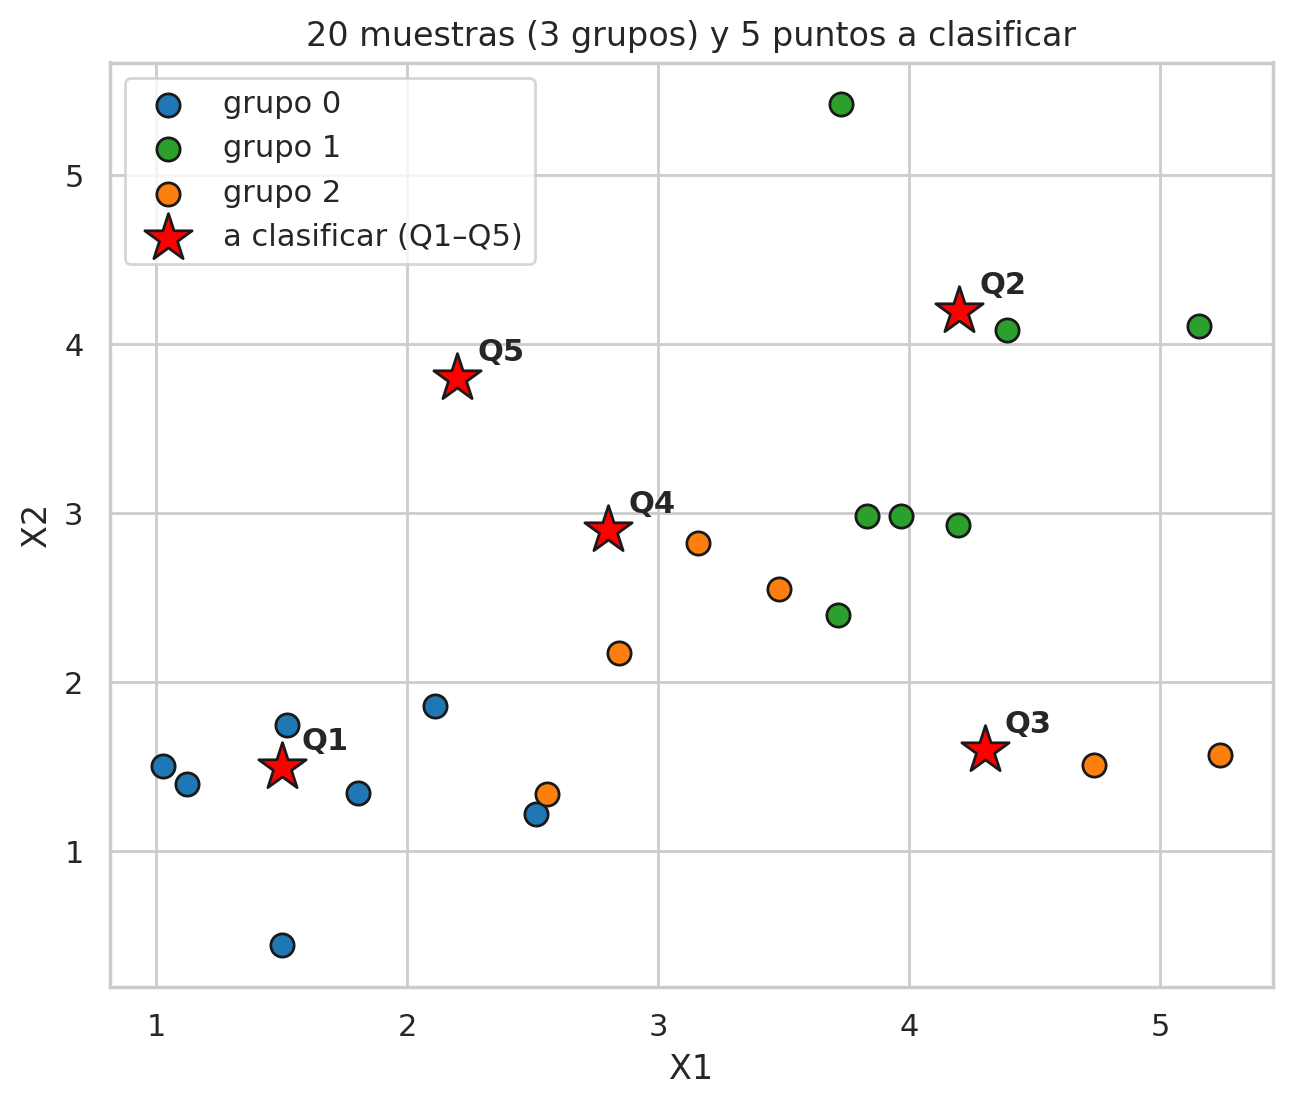

In [ ]:
# Simulamos conjunto de datos  on las especificaciones ddadas
rng = np.random.RandomState(7)
g0 = rng.normal([1.5, 1.5], 0.6, (7, 2))
g1 = rng.normal([4.0, 4.0], 0.7, (7, 2))
g2 = rng.normal([4.0, 1.8], 0.7, (6, 2))
Xtr = np.vstack([g0, g1, g2])
ytr = np.array([0]*7 + [1]*7 + [2]*6)
# 5 observaciones nuevas, repartidas por el espacio
Q = np.array([[1.5, 1.5], [4.2, 4.2], [4.3, 1.6], [2.8, 2.9], [2.2, 3.8]])
colores = np.array(['tab:blue', 'tab:green', 'tab:orange'])
# Gráfico de la nube de pùntos
fig, ax = plt.subplots(figsize=(7.5, 6))
for c in [0, 1, 2]:
    m = ytr == c; ax.scatter(Xtr[m, 0], Xtr[m, 1], color=colores[c], s=70, edgecolor='k', label=f'grupo {c}')
ax.scatter(Q[:, 0], Q[:, 1], marker='*', s=320, color='red', edgecolor='k', label='a clasificar (Q1–Q5)')
for i, (x, y) in enumerate(Q): ax.annotate(f'Q{i+1}', (x+0.08, y+0.10), fontsize=11, weight='bold')
ax.legend(loc='upper left')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('20 muestras (3 grupos) y 5 puntos a clasificar')
plt.show()

## <font color="steelblue">1.1. Etapas del algoritmo</font>

Con la respuesta categórica $y$ y las predictoras $X$ divididas en entrenamiento $(X_e,y_e)$ y test $(X_v,y_v)$, el k-NN de clasificación procede en cinco etapas. Las detallamos pensando en **qué se hace y por qué**:

1. **Fijar $k$.** Elegimos cuántos vecinos votarán. Es la decisión más importante: $k$ pequeño hace caso al detalle local; $k$ grande promedia un vecindario amplio.
2. **Calcular distancias.** Con la distancia elegida, medimos lo lejos que está **cada** punto a clasificar de **todos** los de entrenamiento. El resultado es una tabla de distancias.
3. **Identificar los $k$ vecinos.** Para cada punto nuevo, nos quedamos con los $k$ puntos de entrenamiento de **menor distancia**: son sus "vecinos".
4. **Votar (predicción).** Asignamos la **clase mayoritaria** entre esos $k$ vecinos. Opcionalmente, los vecinos más cercanos pueden **pesar más**.
5. **Validar.** Comparamos las predicciones con las etiquetas reales $y_v$ mediante las métricas de clasificación (exactitud, matriz de confusión…).

A continuación aplicamos el algortimo a nuestro ejemplo de juguete para ver en acción su funcionamiento. Para cada punto Q1–Q5 sus seleccionamos sus **vecinos más cercanos** (aquí con $k=5$), y representamos mediantelíneas las conexiones de dicho punto son su 5 vecinos más cercanos. Ademáa agregamos  el círculo que los engloba.

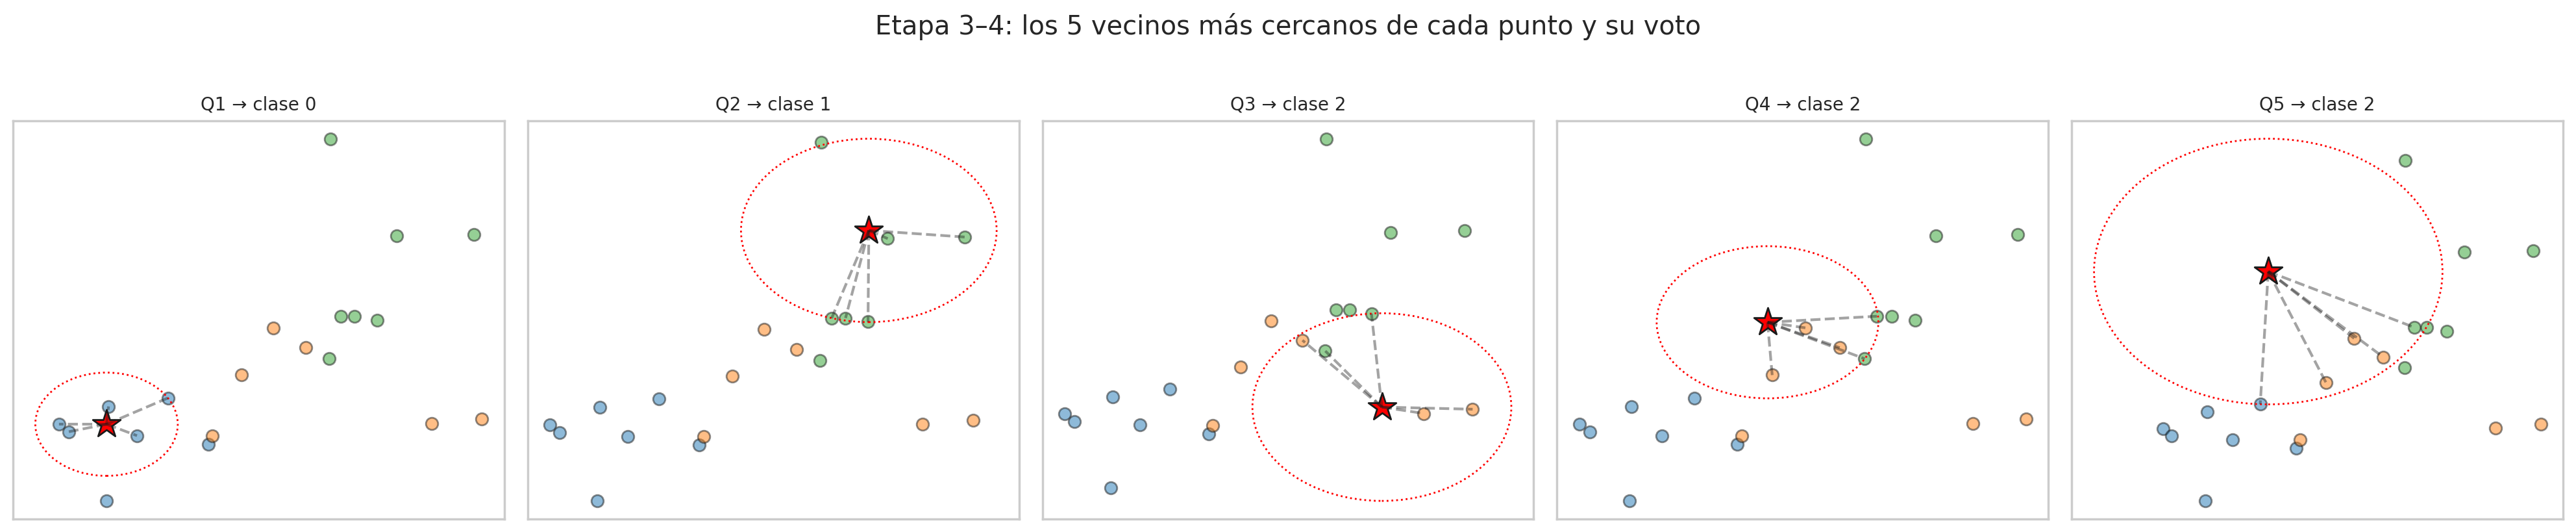

In [ ]:
# Función para ejemplificar el algoritmo
def grafico_vecinos(Xtr, ytr, Q, k, colores):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    pred = knn.predict(Q)
    fig, axes = plt.subplots(1, len(Q), figsize=(4*len(Q), 4))
    for i, a in enumerate(axes):
        q = Q[i]; dist, idx = knn.kneighbors([q]); vec = idx[0]
        for c in [0, 1, 2]:
            m = ytr == c; a.scatter(Xtr[m, 0], Xtr[m, 1], color=colores[c], s=45, alpha=.5, edgecolor='k')
        for v in vec:
            a.plot([q[0], Xtr[v, 0]], [q[1], Xtr[v, 1]], 'k--', alpha=.4)
        a.add_patch(plt.Circle(q, dist[0].max(), color='red', fill=False, ls=':'))
        a.scatter(*q, marker='*', s=260, color='red', edgecolor='k')
        a.set_title(f'Q{i+1} → clase {pred[i]}', fontsize=10)
        a.set_xticks([]); a.set_yticks([])
    plt.suptitle(f'Etapa 3–4: los {k} vecinos más cercanos de cada punto y su voto', y=1.02)
    plt.tight_layout()
    plt.show()

# Solución para cinco puntos de test con k=5
grafico_vecinos(Xtr, ytr, Q, 5, colores)

Cada panel muestra la **etapa 3** (los 5 vecinos dentro del círculo) y la **etapa 4** (la clase mayoritaria, en el título). Q1, Q2 y Q3 caen en el corazón de un grupo, así que su voto es **claro**; Q4 y Q5 están en zonas fronterizas, donde el voto mezcla colores y la decisión es más **delicada** (dependerá de $k$).

Veamos el resulatdo si consideramos 7 vecinos

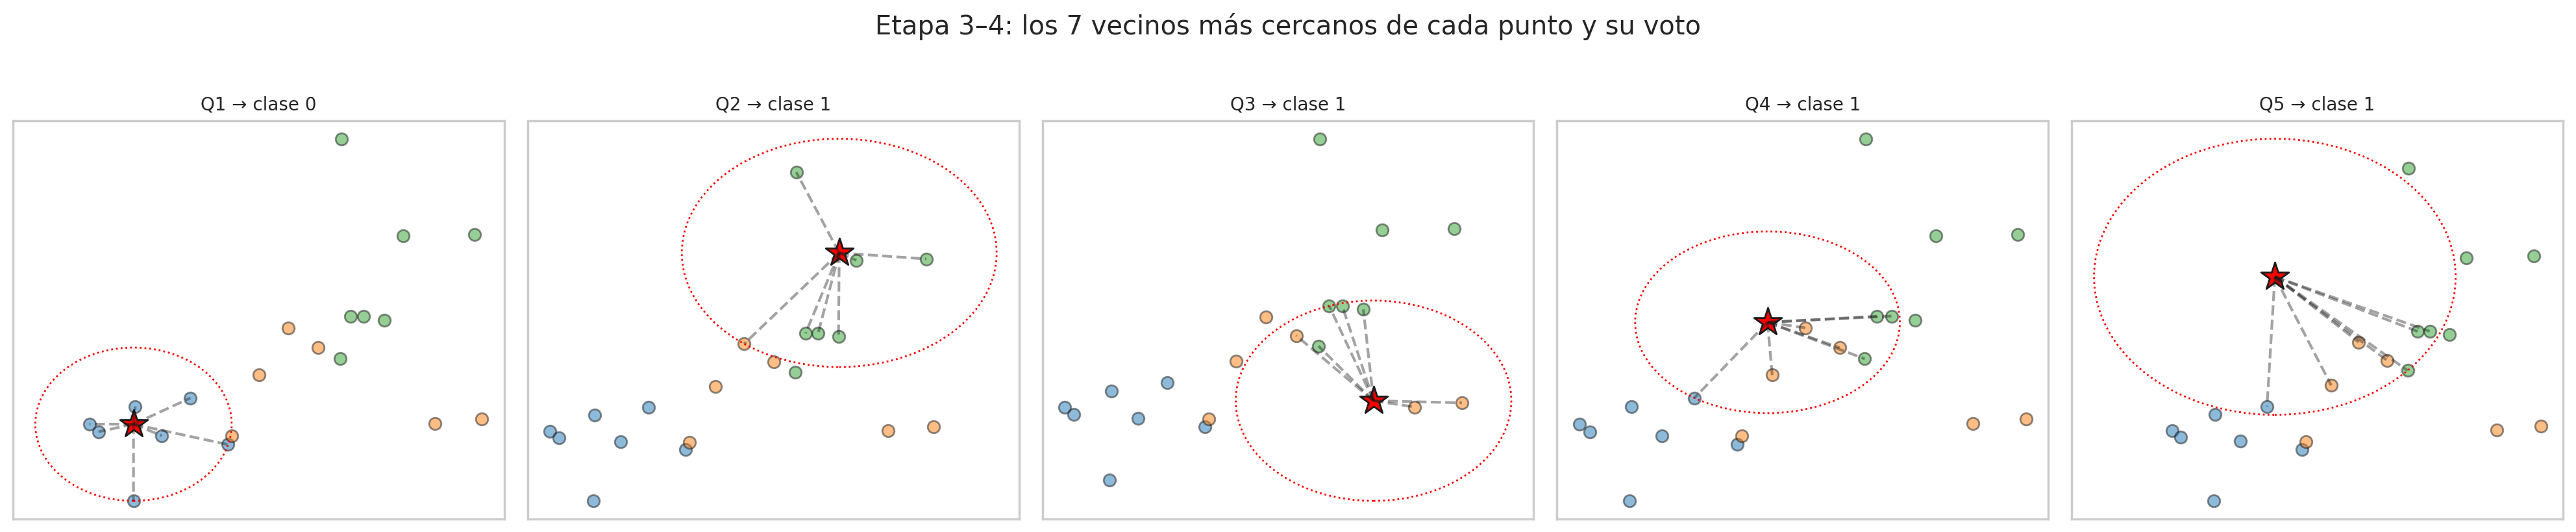

In [ ]:
grafico_vecinos(Xtr, ytr, Q, 7, colores)

Analizamos con algo más detalle la etapa 2 para el caso de k=5. En este caso proporcioanmos el lsitados de vecinos y la distancia a la que se encuentran apra un punto específico de los cinco que intentamos predecir. Tomamos el cuarto punto de la lista proporcionada `Q`:

In [ ]:
k = 5; q = Q[3]   # Q4, un punto fronterizo
knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
dist, idx = knn.kneighbors([q])
tabla = pd.DataFrame({'grupo_vecino': ytr[idx[0]], 'distancia': np.round(dist[0], 2)})
print('Etapa 2-3 para Q4 — sus 5 vecinos más cercanos:')
print(tabla.to_string(index=False))
print('\nEtapa 4 (voto): conteo por clase', np.bincount(ytr[idx[0]], minlength=3).tolist(), '-> clase', knn.predict([q])[0])

Etapa 2-3 para Q4 — sus 5 vecinos más cercanos:
 grupo_vecino  distancia
            2       0.37
            2       0.73
            2       0.76
            1       1.03
            1       1.04

Etapa 4 (voto): conteo por clase [0, 2, 3] -> clase 2


Para Q4 listamos sus 5 vecinos ordenados por distancia y contamos sus clases: la mayoría determina la predicción. Fíjate en que algunos vecinos están bastante más lejos que otros; esa idea motivará la **ponderación**.

## <font color="steelblue">1.2. Métricas de distancia</font>

La "cercanía" depende de la **distancia** elegida. Las más habituales (con $p$ predictoras, entre los puntos $x$ y $z$) son:

* **Euclídea** (la línea recta, solo predictoras numéricas): $d=\sqrt{\sum_l (x_l-z_l)^2}$.
* **Manhattan** (suma de diferencias absolutas, como recorrer una cuadrícula de calles): $d=\sum_l |x_l-z_l|$.
* **Minkowski** (generaliza ambas con un parámetro $g$): $d=\left(\sum_l |x_l-z_l|^g\right)^{1/g}$; con $g=2$ es euclídea y con $g=1$, Manhattan.
* **Chebyshev**: es la **mayor** de las diferencias en una sola coordenada, $d=\max_l |x_l-z_l|$. Equivale a Minkowski con $g\to\infty$. Mide la cercanía por la **peor** dimensión: dos puntos son cercanos solo si lo son en **todas** las coordenadas. Es útil cuando un único desajuste grande en cualquier variable debe bastar para considerar lejanos dos puntos (p. ej. movimientos en rejillas o controles de tolerancia).
* **Hamming** (para variables **categóricas, booleanas o de cadena**): cuenta en **cuántas posiciones difieren** los dos vectores (dividido entre el nº de posiciones si se quiere en proporción). No mide "cuánto" difieren, solo **si** difieren: por eso es la métrica natural para atributos sin orden numérico (color, sí/no, código postal…). Cuidado con variables **ordinales** (p. ej. "bajo/medio/alto"): Hamming las trata como simples categorías y **no respeta el orden**.

Cuando hay variables numéricas y categóricas a la vez, se pueden **combinar** (euclídea para las numéricas, Hamming para las categóricas). La distancia es, junto con $k$ (número de vecinos a considerar), un **hiperparámetro** que optimizaremos.

**Visualizando la matriz de distancias**

Para entender mejor comp se seleccionan los vecinos con las diatncias consideradas vamos a calcular la **matriz de distancias** entre las 20 muestras de entrenamiento (ordenadas por grupo). Las zonas **oscuras** (distancia pequeña) deberían formar **bloques** en la diagonal (puntos del mismo grupo, cercanos) y zonas claras entre grupos distintos.

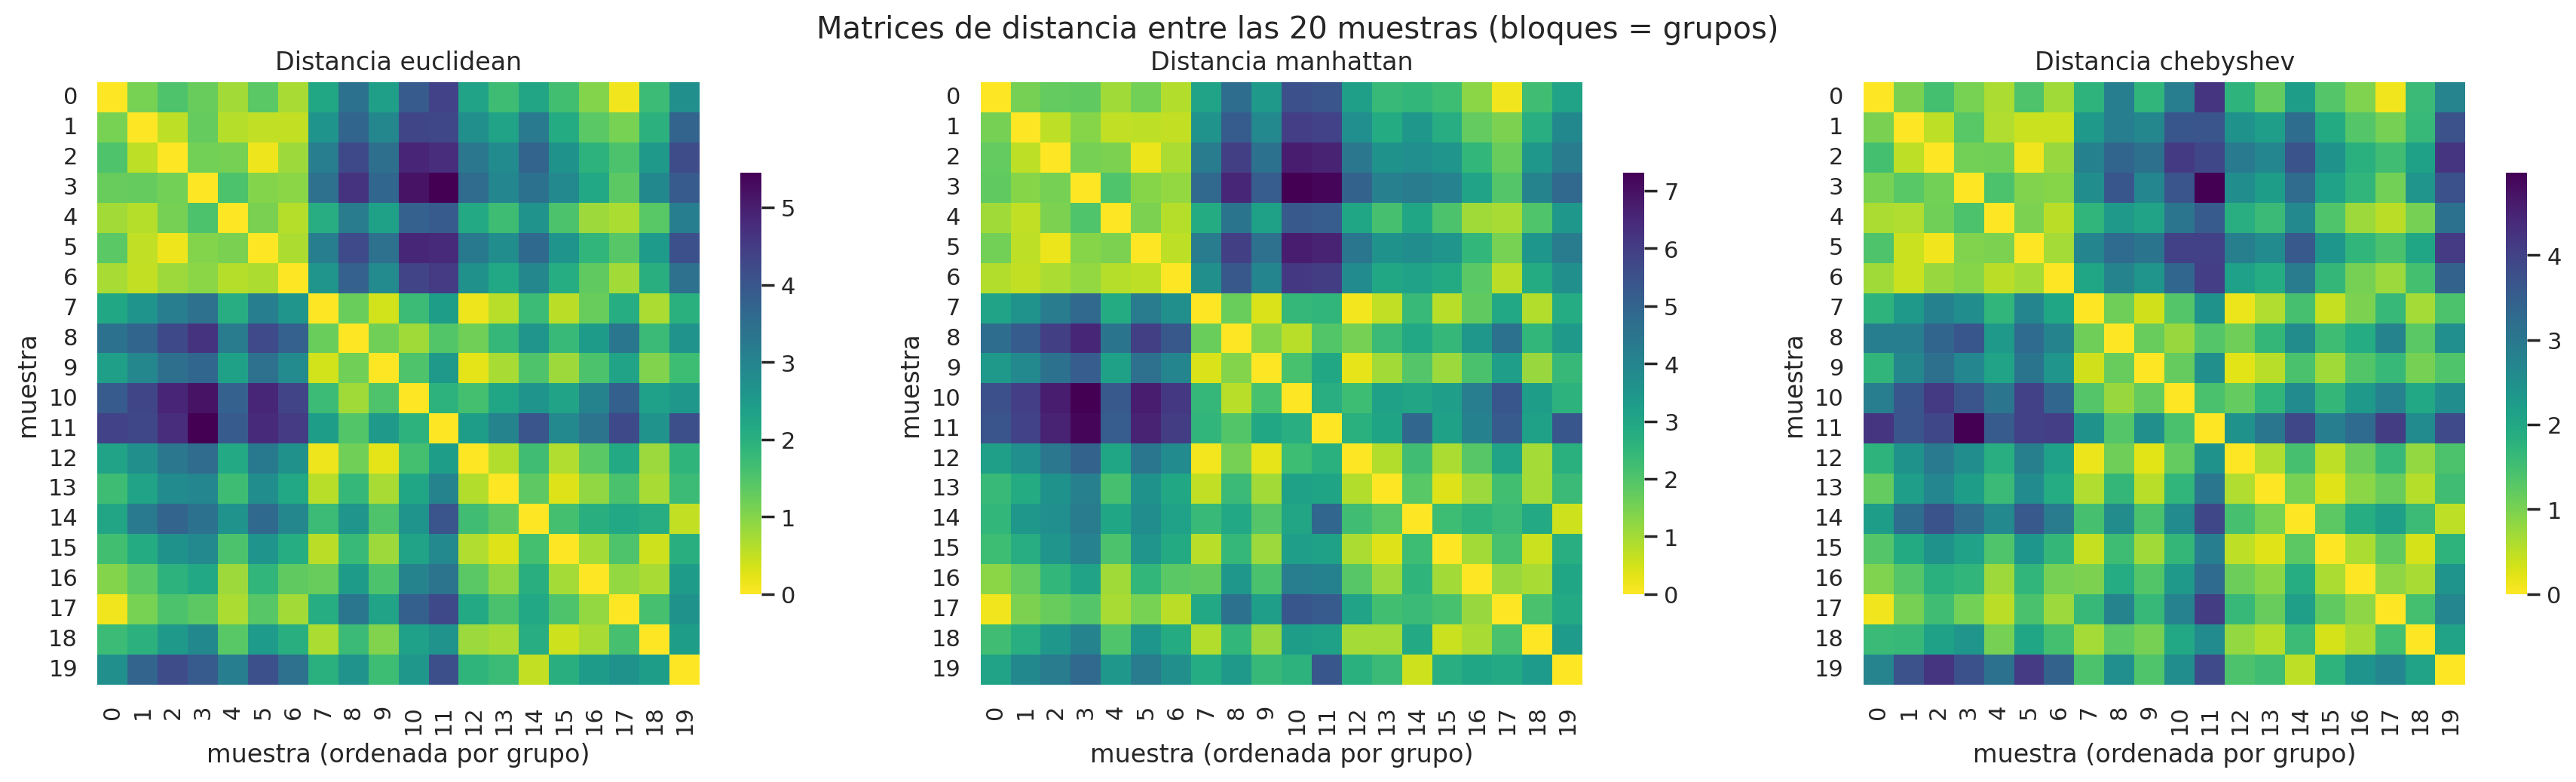

In [ ]:
# Heatmap de distancias entre puntos del ejemplo para tres distancias
orden = np.argsort(ytr)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, met in zip(ax, ['euclidean', 'manhattan', 'chebyshev']):
    D = pairwise_distances(Xtr[orden], metric=met)
    sns.heatmap(D, ax=a, cmap='viridis_r', square=True, cbar_kws={'shrink': .7})
    a.set_title(f'Distancia {met}'); a.set_xlabel('muestra (ordenada por grupo)')
    a.set_ylabel('muestra')
plt.suptitle('Matrices de distancia entre las 20 muestras (bloques = grupos)')
plt.tight_layout()
plt.show()

En las tres matrices se aprecian **bloques oscuros** en la diagonal: los puntos de un mismo grupo están cerca entre sí. Las tres métricas dan una estructura **parecida** (mismos bloques) pero con **escalas e intensidades distintas**: Manhattan tiende a dar valores mayores (suma todas las diferencias) y Chebyshev menores (solo la mayor). Esa diferencia explica que la métrica influya en qué vecinos se eligen, sobre todo en las fronteras.

Para la distancia **Hamming**, que es categórica, usamos un mini-ejemplo aparte (no aplica a datos numéricos): cuatro clientes descritos por atributos cualitativos.

In [ ]:
clientes = pd.DataFrame({'color_favorito': ['rojo', 'azul', 'rojo', 'verde'],
                         'fumador':        ['si',   'no',   'si',   'no'],
                         'ciudad':         ['Elche','Elche','Madrid','Elche']}, index=['C1','C2','C3','C4'])
print(clientes, '\n')
# Hamming = proporción de atributos en los que difieren
D_ham = pairwise_distances(pd.get_dummies(clientes).values, metric='hamming')
print('Matriz de distancia de Hamming (proporción de atributos distintos):')
print(pd.DataFrame(np.round(D_ham, 2), index=clientes.index, columns=clientes.index))

   color_favorito fumador  ciudad
C1           rojo      si   Elche
C2           azul      no   Elche
C3           rojo      si  Madrid
C4          verde      no   Elche 

Matriz de distancia de Hamming (proporción de atributos distintos):
      C1    C2    C3    C4
C1  0.00  0.57  0.29  0.57
C2  0.57  0.00  0.86  0.29
C3  0.29  0.86  0.00  0.86
C4  0.57  0.29  0.86  0.00


C1 y C3 solo difieren en la ciudad → distancia pequeña; C1 y C2 difieren en color y fumador → distancia mayor. Hamming cuenta **en cuántos atributos no coinciden**, sin importar "cuánto", que es justo lo que necesitamos con variables sin orden numérico.

## <font color="steelblue">1.3. Predictoras irrelevantes y problemas de escala</font>

Como k-NN decide por distancias, es **muy sensible** a:

* **La escala.** Una variable con rango grande (p. ej. [0, 1000]) **domina** la distancia frente a otra en [0, 1], anulándola. La solución es **estandarizar** para que todas pesen igual.
* **Las predictoras irrelevantes.** Variables que no informan **diluyen** la distancia; si son mayoría, los "vecinos" dejan de ser significativos (*maldición de la dimensión*). Conviene **seleccionar** las relevantes; lo ilustraremos con el estadístico **F de ANOVA** (`f_classif`).





## <font color="steelblue">1.4. La importancia de elegir el número de vecinos $k$</font>

El valor de $k$ es el **hiperparámetro más determinante** del algoritmo y gobierna un **compromiso sesgo–varianza**:

* **$k$ pequeño** (en el extremo, $k=1$): la predicción depende de **uno o muy pocos** vecinos, así que la frontera se adapta a **cada punto**, incluido el ruido. Resultado: fronteras muy **irregulares**, baja "estabilidad", riesgo de **sobreajuste** (mucha varianza).
* **$k$ grande**: la decisión promedia un vecindario **amplio**, suavizando la frontera y ganando estabilidad. Pero si $k$ es **excesivo**, se diluye la estructura local y todo tiende a la **clase mayoritaria** global: aparece el **infraajuste** (mucho sesgo).

Lo vemos sobre el juguete de dos formas. Primero, **cómo cambia la clase predicha** de los 5 puntos al variar $k$ considerando que todos los vecinos tienen el mismo peso en la predicción (`voto uniforme`):

In [ ]:
ks = [1, 3, 5, 7, 9, 11, 15]
tabla_k = pd.DataFrame({f'k={k}': KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr).predict(Q) for k in ks},
                       index=[f'Q{i+1}' for i in range(len(Q))])
print('Clase predicha para cada punto según k (voto uniforme):')
print(tabla_k)

Clase predicha para cada punto según k (voto uniforme):
    k=1  k=3  k=5  k=7  k=9  k=11  k=15
Q1    0    0    0    0    0     0     0
Q2    1    1    1    1    1     1     1
Q3    2    2    2    1    2     2     1
Q4    2    2    2    1    1     1     0
Q5    2    2    2    1    1     1     1


Representamso ahora las regiones de decisión en función de `k` (el color de fondo es la clase que se asignaría a cada zona). Superponemos los cinco puntos de test para valorar el grupo asignado.

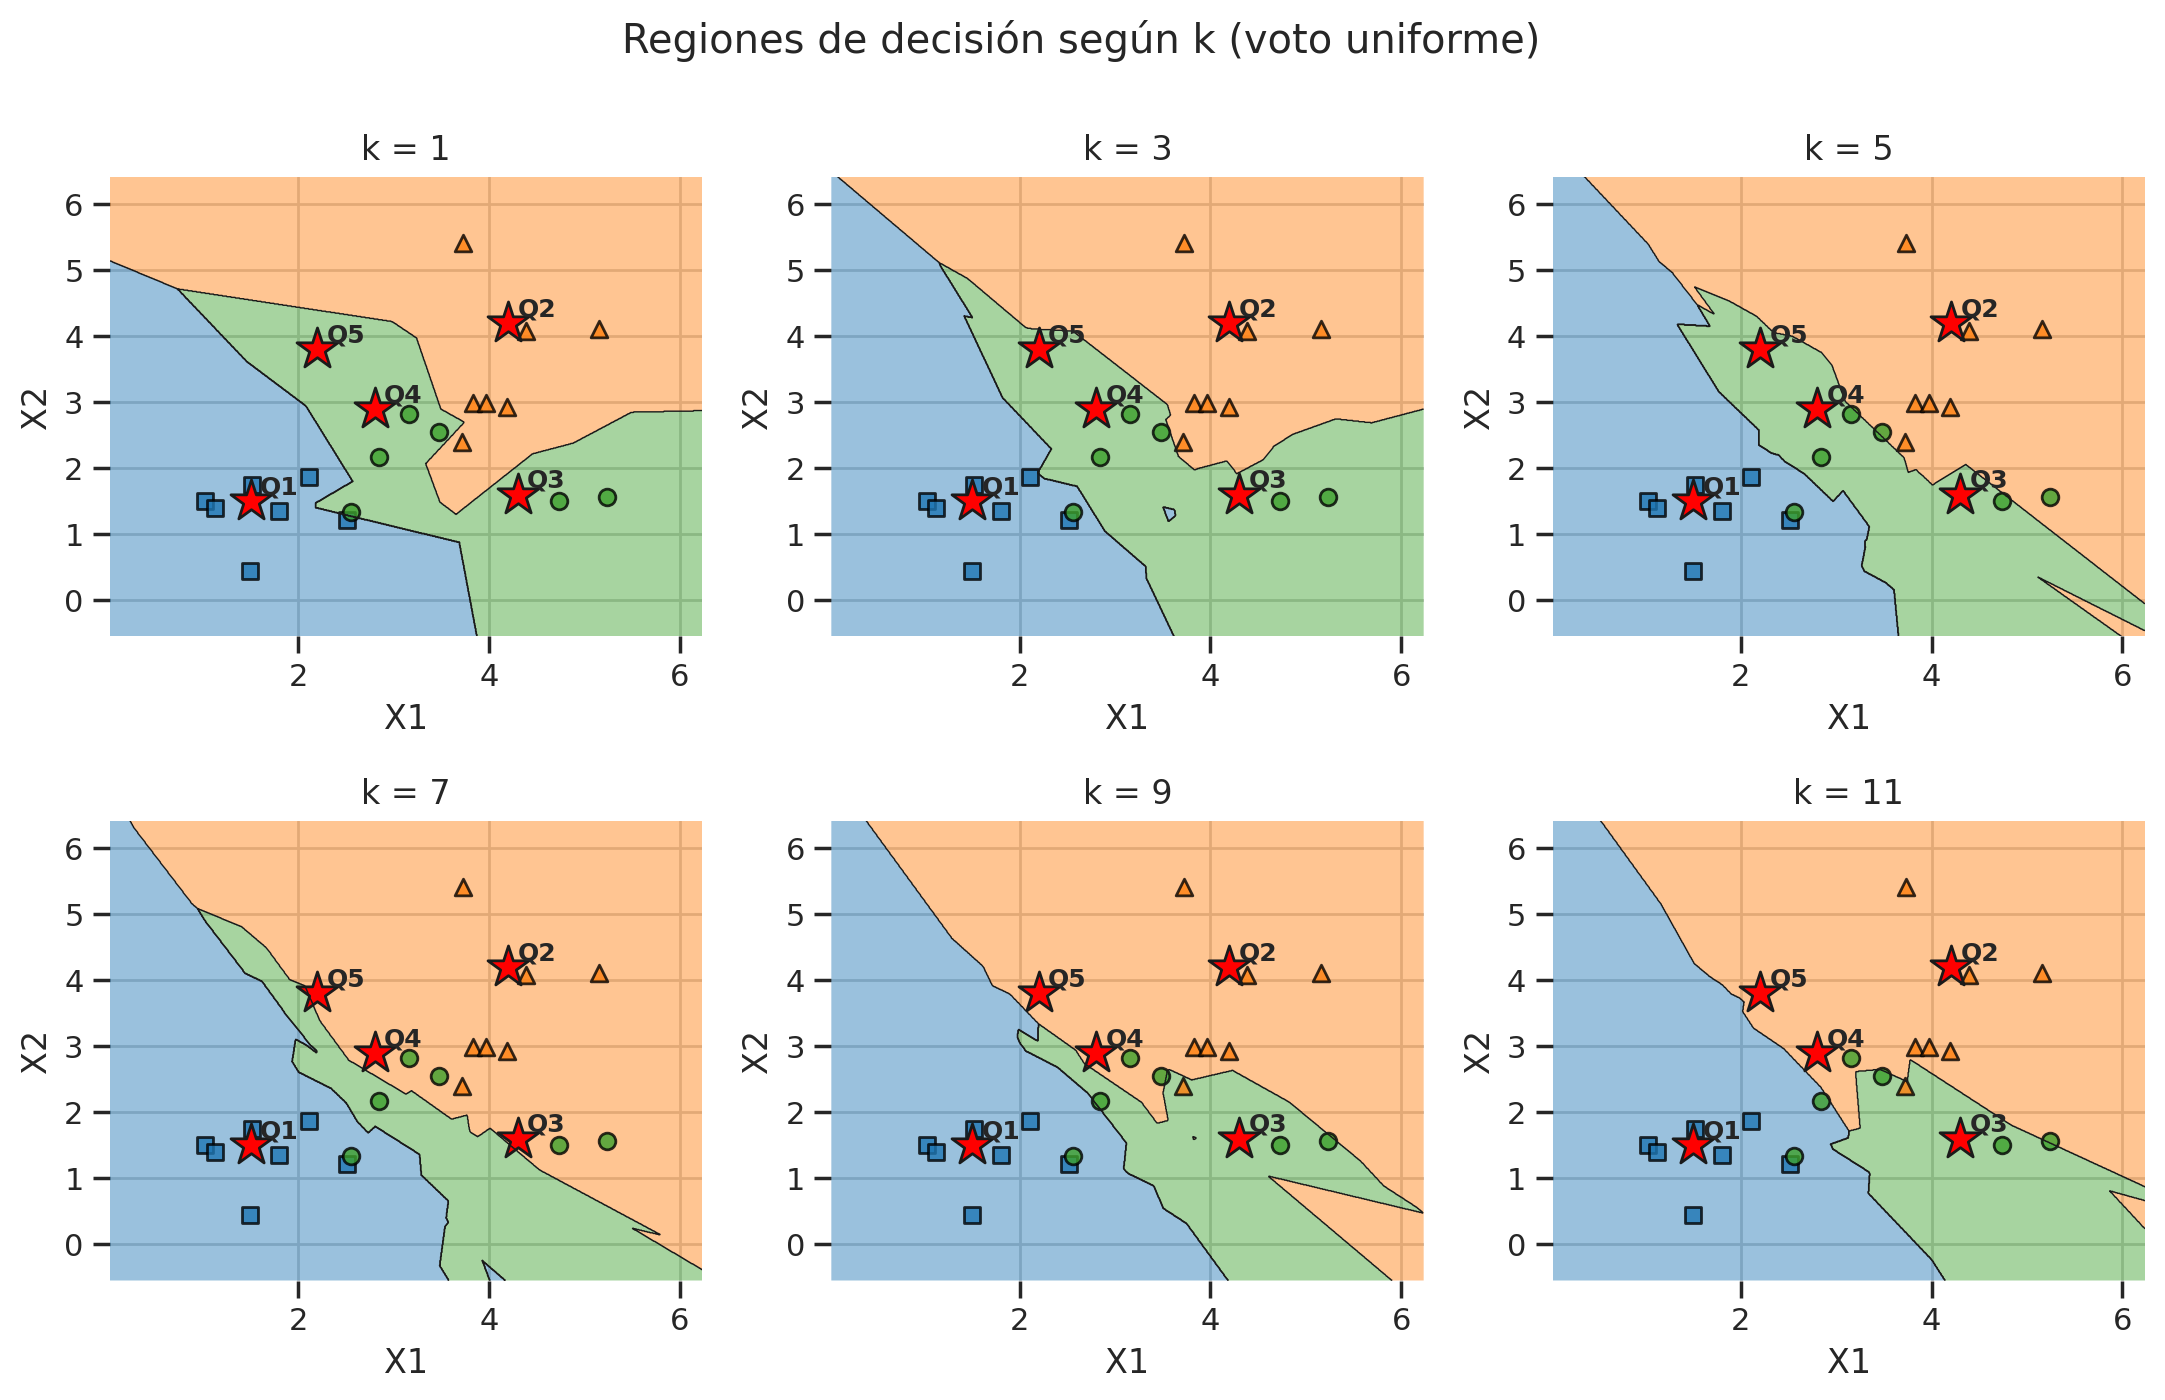

In [ ]:
ks = [1, 3, 5, 7, 9, 11]
fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for a, k in zip(ax.ravel(), ks):
    modelo = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    plot_decision_regions(X=Xtr, y=ytr, clf=modelo, ax=a, legend=0)
    a.scatter(Q[:, 0], Q[:, 1], marker='*', s=240, color='red', edgecolor='k')
    for i, (x, y) in enumerate(Q): a.annotate(f'Q{i+1}', (x+0.1, y+0.1), fontsize=9, weight='bold')
    a.set_title(f'k = {k}')
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.suptitle('Regiones de decisión según k (voto uniforme)', y=1.0)
plt.tight_layout()
plt.show()

Con **$k=1$** la frontera es muy "irregular" (cada punto domina su entorno): máximo detalle, máxima sensibilidad al ruido. Al **aumentar $k$**, las regiones se **suavizan**. En la tabla y los mapas se ve que **Q1, Q2 y Q3** (en el corazón de sus grupos) son **estables**, mientras que **Q4 y Q5** (fronterizos) **cambian de clase** según $k$, e incluso un punto puede "perder" su grupo si $k$ crece tanto que el vecindario abarca un grupo vecino más numeroso. La lección: hay que **buscar el $k$** que ni se deja llevar por el ruido (muy pequeño) ni borra la estructura local (muy grande), y eso se hace por **validación cruzada**.



## <font color="steelblue">1.5. Ponderación de los vecinos</font>

En el voto **uniforme**, los $k$ vecinos cuentan **igual**, estén cerca o lejos. Esto puede dar decisiones discutibles cuando las distancias son muy dispares. La **ponderación por distancia** (`weights='distance'`) corrige esto dando a cada vecino un **peso inversamente proporcional a su distancia** ($w_i=1/d_i$): los más cercanos **pesan más**. Veámoslo en un caso concreto del juguete, **Q4 con $k=7$**:

In [ ]:
k = 7; q = Q[3]   # Q4
knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
dist, idx = knn.kneighbors([q]); cl = ytr[idx[0]]
tab = pd.DataFrame({'grupo': cl, 'distancia': np.round(dist[0], 2), 'peso (1/d)': np.round(1/dist[0], 2)})
print('Vecinos de Q4 (k=7):'); print(tab.to_string(index=False))
pesos = np.zeros(3)
for c, w in zip(cl, 1/dist[0]): pesos[c] += w
print('\nVoto UNIFORME  -> conteo', np.bincount(cl, minlength=3).tolist(),
      '-> clase', KNeighborsClassifier(n_neighbors=k, weights='uniform').fit(Xtr, ytr).predict([q])[0])
print('Voto PONDERADO -> pesos ', np.round(pesos, 2).tolist(),
      '-> clase', KNeighborsClassifier(n_neighbors=k, weights='distance').fit(Xtr, ytr).predict([q])[0])

Vecinos de Q4 (k=7):
 grupo  distancia  peso (1/d)
     2       0.37        2.74
     2       0.73        1.38
     2       0.76        1.31
     1       1.03        0.97
     1       1.04        0.96
     1       1.17        0.85
     0       1.25        0.80

Voto UNIFORME  -> conteo [1, 3, 3] -> clase 1
Voto PONDERADO -> pesos  [0.8, 2.78, 5.42] -> clase 2


Con $k=7$, el voto **uniforme** reparte los vecinos casi a partes iguales y elige una clase aunque sus vecinos estén **más lejos**; el voto **ponderado** detecta que los **vecinos más próximos** a Q4 son de otra clase y, al pesar más, **cambia la predicción**. Igual que hicimos con $k$, comparamos las **clases predichas** de los 5 puntos con ambas ponderaciones a lo largo de $k$:

In [ ]:
ks = [1, 3, 5, 7, 9, 11, 15]
tab_u = pd.DataFrame({f'k={k}': KNeighborsClassifier(n_neighbors=k, weights='uniform').fit(Xtr, ytr).predict(Q) for k in ks}, index=[f'Q{i+1}' for i in range(5)])
tab_d = pd.DataFrame({f'k={k}': KNeighborsClassifier(n_neighbors=k, weights='distance').fit(Xtr, ytr).predict(Q) for k in ks}, index=[f'Q{i+1}' for i in range(5)])
print('Voto UNIFORME:'); print(tab_u)
print('\nVoto PONDERADO por distancia:'); print(tab_d)

Voto UNIFORME:
    k=1  k=3  k=5  k=7  k=9  k=11  k=15
Q1    0    0    0    0    0     0     0
Q2    1    1    1    1    1     1     1
Q3    2    2    2    1    2     2     1
Q4    2    2    2    1    1     1     0
Q5    2    2    2    1    1     1     1

Voto PONDERADO por distancia:
    k=1  k=3  k=5  k=7  k=9  k=11  k=15
Q1    0    0    0    0    0     0     0
Q2    1    1    1    1    1     1     1
Q3    2    2    2    2    2     2     2
Q4    2    2    2    2    2     2     2
Q5    2    2    2    2    1     1     1


Y la misma vista **gráfica** que en 1.4, ahora en dos filas (uniforme arriba, ponderado abajo) para apreciar las diferencias **a la vez** según el método de ponderación y según $k$.

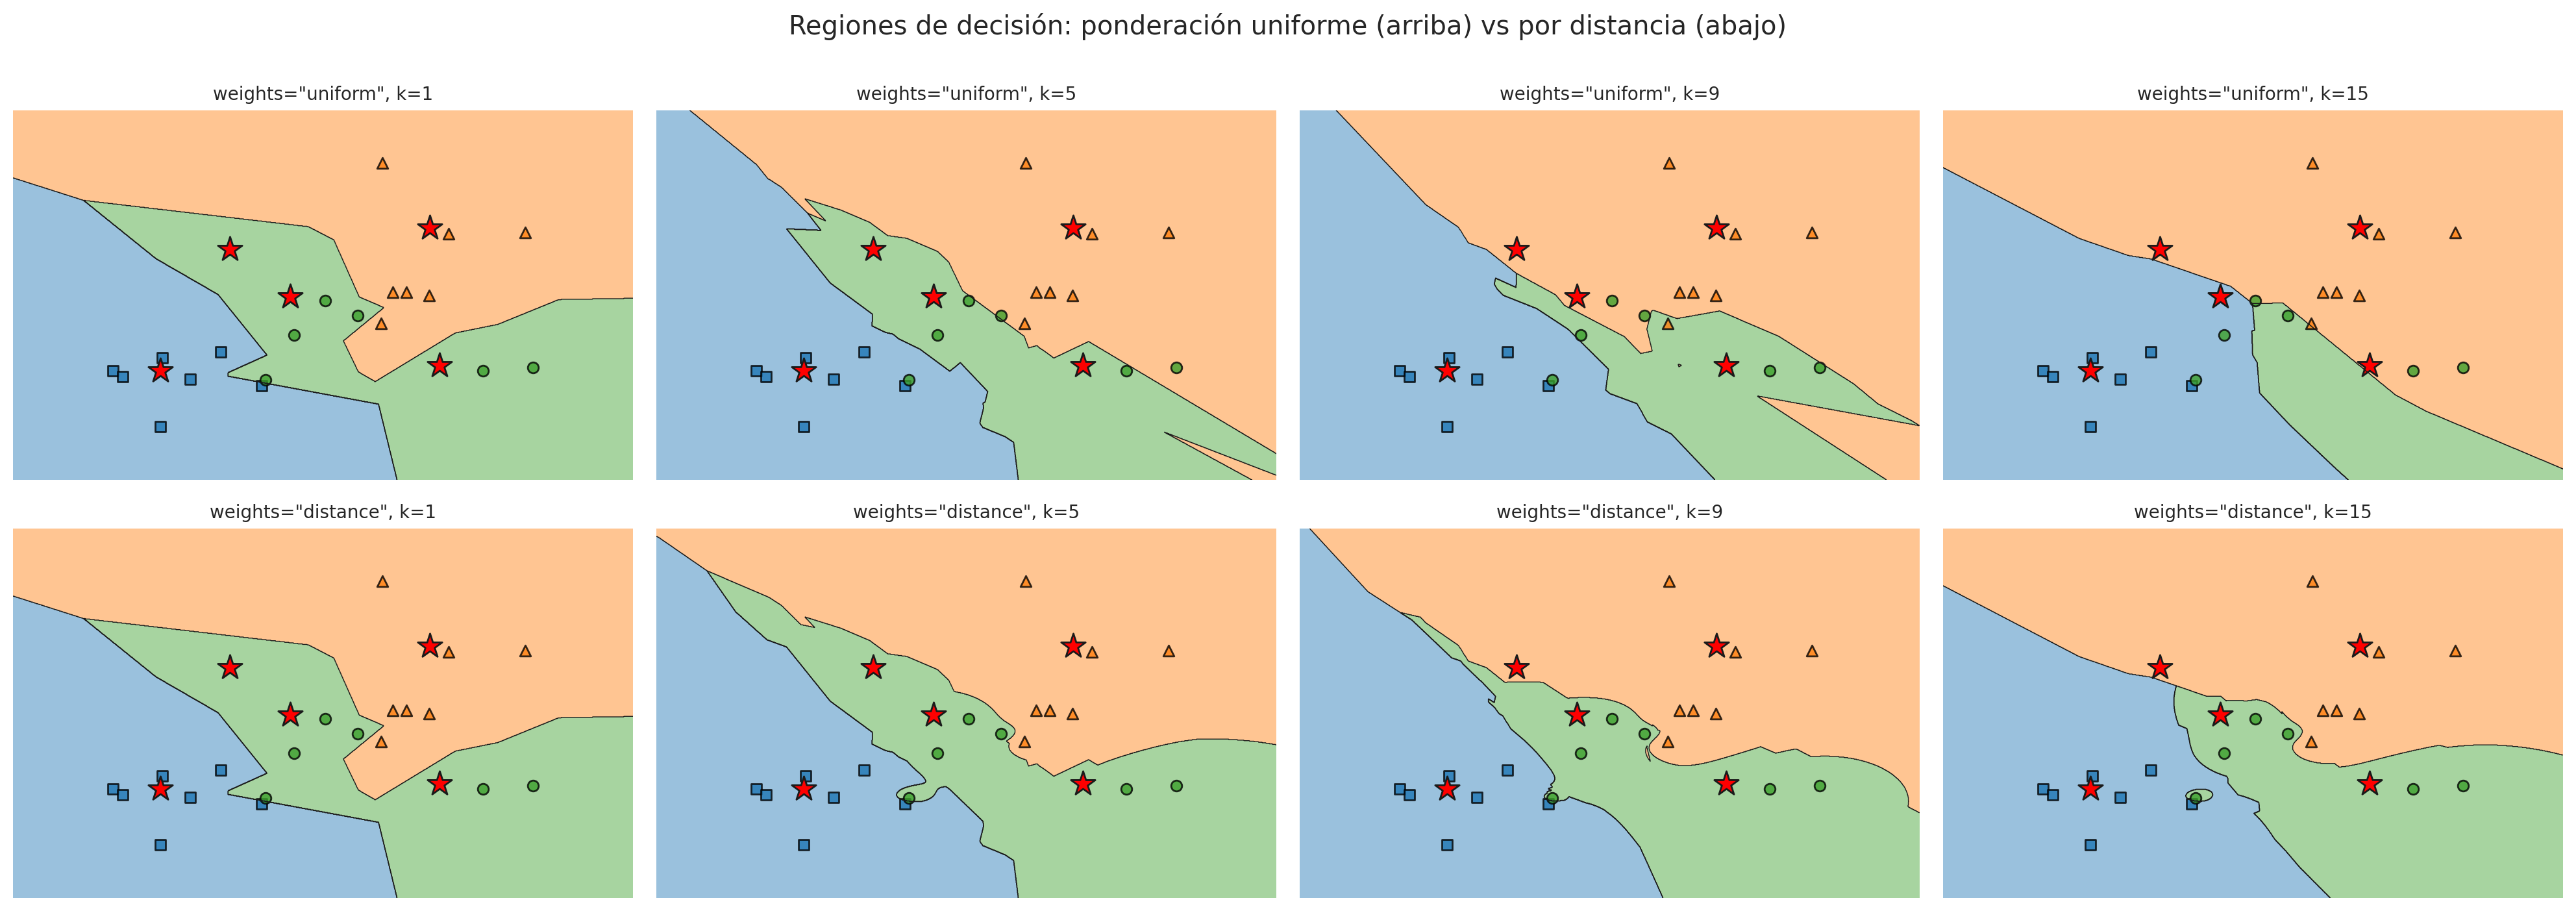

In [ ]:
ks = [1, 5, 9, 15]
fig, ax = plt.subplots(2, len(ks), figsize=(5*len(ks), 7))
for fila, w in enumerate(['uniform', 'distance']):
    for col, k in enumerate(ks):
        a = ax[fila, col]
        modelo = KNeighborsClassifier(n_neighbors=k, weights=w).fit(Xtr, ytr)
        plot_decision_regions(X=Xtr, y=ytr, clf=modelo, ax=a, legend=0)
        a.scatter(Q[:, 0], Q[:, 1], marker='*', s=200, color='red', edgecolor='k')
        a.set_title(f'weights="{w}", k={k}', fontsize=10)
        a.set_xticks([])
        a.set_yticks([])
plt.suptitle('Regiones de decisión: ponderación uniforme (arriba) vs por distancia (abajo)', y=1.0)
plt.tight_layout()
plt.show()

La ponderación por distancia produce fronteras que se **ajustan más** a los puntos cercanos y, sobre todo, es **más robusta a un $k$ grande**: mientras el voto uniforme con $k$ alto tiende a "tragarse" los puntos fronterizos hacia el grupo más numeroso, el ponderado **conserva mejor** la clase de los vecinos próximos (compara las tablas: con `distance`, Q3 y Q4 se mantienen estables más tiempo). En la práctica, `weights` es otro **hiperparámetro** a optimizar junto con $k$ y la distancia.

## <font color="steelblue">1.6. Ventajas y desventajas</font>

**Ventajas:** simple e intuitivo; no asume hipótesis sobre los datos; se adapta al añadir muestras; sirve para clasificación y regresión. **Desventajas:** **lento al predecir** con muchos datos; consume **memoria** (guarda todo el entrenamiento); sufre con **muchas predictoras** (maldición de la dimensión), con el **desbalanceo** y con la **escala**. La elección de $k$, la distancia y la ponderación es determinante.



# <font color="steelblue">2. k-NN en scikit-learn</font>

La clase para modelos de clasificación es **`KNeighborsClassifier`**. Sus parámetros, **completos**, son:

| Parámetro | Descripción | Valor por defecto |
|---|---|---|
| **`n_neighbors`** | El número de vecinos $k$. | `5` |
| **`weights`** | Ponderación de los vecinos: `'uniform'` (todos igual), `'distance'` (peso $1/d$) o una función propia. | `'uniform'` |
| **`algorithm`** | Estructura de búsqueda de vecinos: `'auto'`, `'ball_tree'`, `'kd_tree'`, `'brute'`. Afecta a la **velocidad**, no al resultado. | `'auto'` |
| **`leaf_size`** | Tamaño de hoja de los árboles (`ball_tree`/`kd_tree`); afecta a velocidad y memoria. | `30` |
| **`p`** | Parámetro de la distancia de Minkowski: `1` = Manhattan, `2` = euclídea. | `2` |
| **`metric`** | La distancia: `'minkowski'` (con `p`), `'euclidean'`, `'manhattan'`, `'chebyshev'`, `'hamming'`, etc. | `'minkowski'` |
| **`metric_params`** | Argumentos adicionales para métricas que lo requieran. | `None` |
| **`n_jobs`** | Núcleos de CPU para el cálculo de vecinos (`-1` = todos). | `None` |

**Métodos y resultados** que podemos obtener destacan:
* `fit(X, y)` (entrena el modelo),
* `predict(X)` (clase predicha por el modelo),
* `predict_proba(X)` (proproporción de vecinos de cada clase),
* `kneighbors(X)` (distancias e índices de los vecinos),
* `kneighbors_graph(X)` (grafo de vecindad),
* `score(X, y)` (exactitud).

**Atributos**: `classes_`, `n_features_in_`, `effective_metric_`.

Vemos muchos de ellos sobre el ejemplo considerado.

In [ ]:
modelo = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
print('classes_:', modelo.classes_, '| effective_metric_:', modelo.effective_metric_)
print('\npredict(Q):       ', modelo.predict(Q))
print('predict_proba(Q):\n', np.round(modelo.predict_proba(Q), 2))
dist, idx = modelo.kneighbors(Q[:2])
print('\nkneighbors(Q1,Q2) — distancias:\n', np.round(dist, 2))
print('kneighbors(Q1,Q2) — índices de los vecinos:\n', idx)

classes_: [0 1 2] | effective_metric_: euclidean

predict(Q):        [0 1 2 2 2]
predict_proba(Q):
 [[1.  0.  0. ]
 [0.  1.  0. ]
 [0.  0.4 0.6]
 [0.  0.4 0.6]
 [0.2 0.2 0.6]]

kneighbors(Q1,Q2) — distancias:
 [[0.25 0.34 0.39 0.47 0.71]
 [0.22 0.96 1.24 1.27 1.27]]
kneighbors(Q1,Q2) — índices de los vecinos:
 [[ 1  6  5  2  4]
 [ 8 10 12  9  7]]


`predict_proba` no es una probabilidad "de modelo" sino la **proporción de vecinos** de cada clase (con $k=5$, múltiplos de 0.2); sirve para la curva ROC y para medir la "seguridad". `kneighbors` permite **auditar** cada decisión viendo quiénes son los vecinos y a qué distancia.

Podemos ver gráficamente los vecinos considerados para cada punto dentro del conjunto Q.

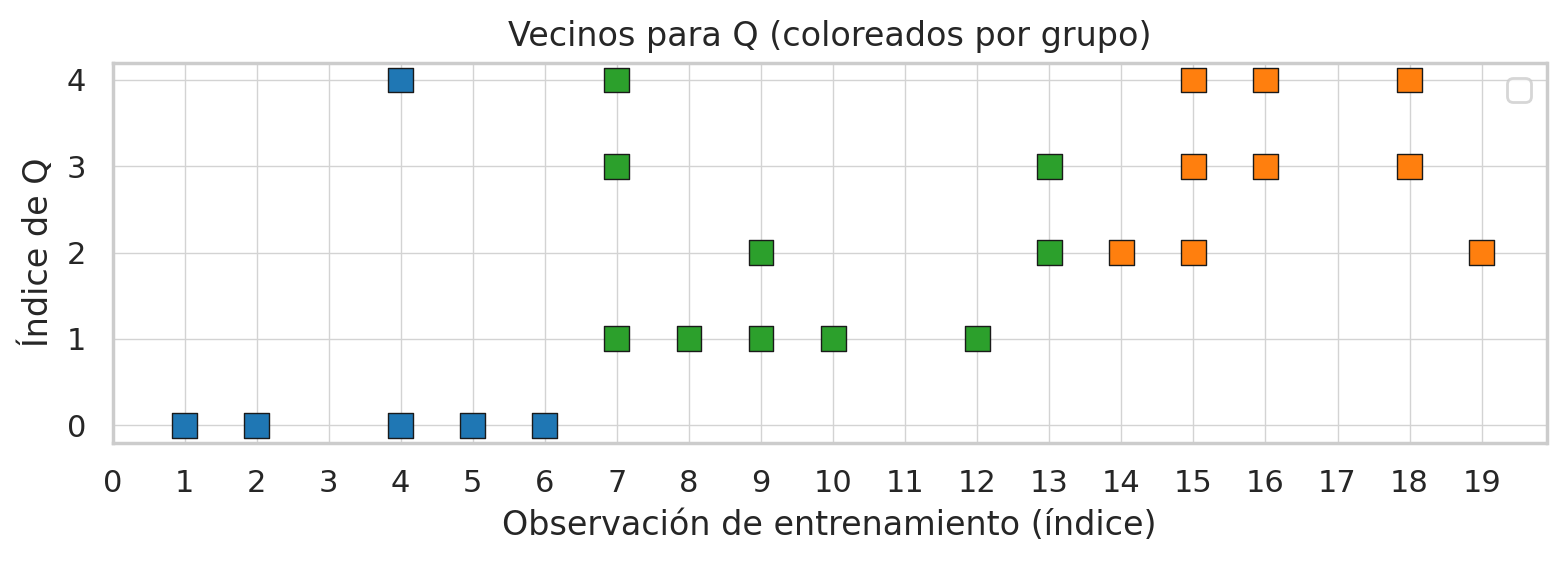

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))

sparse_graph = modelo.kneighbors_graph(Q[:5])
row_indices, col_indices = sparse_graph.nonzero()
point_colors = colores[ytr[col_indices]]
ax.scatter(col_indices, row_indices, c=point_colors, marker='s', s=80, edgecolor='k', linewidth=0.5)
ax.set_title('Vecinos para Q (coloreados por grupo)')
ax.set_xlabel('Observación de entrenamiento (índice)')
ax.set_ylabel('Índice de Q')
ax.set_xticks(np.arange(len(Xtr)))
ax.set_yticks(np.arange(len(Q[:5])))
ax.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5)

import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colores[c], label=f'Grupo {c}') for c in np.unique(ytr)]
ax.legend(handles=legend_handles, title='Grupos de $X_{tr}$', loc='lower right')
plt.legend()
plt.tight_layout()
plt.show()



# <font color="steelblue">3. Aplicaciones</font>

Aplicamos el algoritmo k-NN a dos problemas de clasificación, usando las funciones del curso para preprocesar y evaluar. Para elegir $k$, la **distancia** y la **ponderación** usamos `GridSearchCV`, con esta función auxiliar que muestra la **validación cruzada gráficamente**.

In [ ]:
# Función para representar la solución óptima para los hiperparámetros de Knn
def cv_grafica(gs, metricas, titulo):
    r = pd.DataFrame(gs.cv_results_)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for a, w in zip(ax, ['uniform', 'distance']):
        for met in metricas:
            sub = r[(r.param_weights == w) & (r.param_metric == met)].sort_values('param_n_neighbors')
            a.plot(sub.param_n_neighbors, sub.mean_test_score, marker='.', label=met)
        a.set_title(f'weights = {w}')
        a.set_xlabel('nº de vecinos (k)')
        a.legend(title='distancia')
        a.grid(True, alpha=.3)
    ax[0].set_ylabel('exactitud (validación cruzada)')
    b = gs.best_params_
    plt.suptitle(f"{titulo} — óptimo: k={b['n_neighbors']}, {b['metric']}, {b['weights']} (acc CV={gs.best_score_:.3f})")
    plt.tight_layout()
    plt.show()

## <font color="steelblue">3.1. Breast Cancer Wisconsin (2 clases)</font>

Recuperamos el ejemplo de breast cancer donde deseamos clasificar tumores como **benignos (B)** o **malignos (M)** a partir de 30 características de los núcleos celulares.

Cargamos los datos y rerpesentamso el reparto del target

Dimensiones: (569, 31)


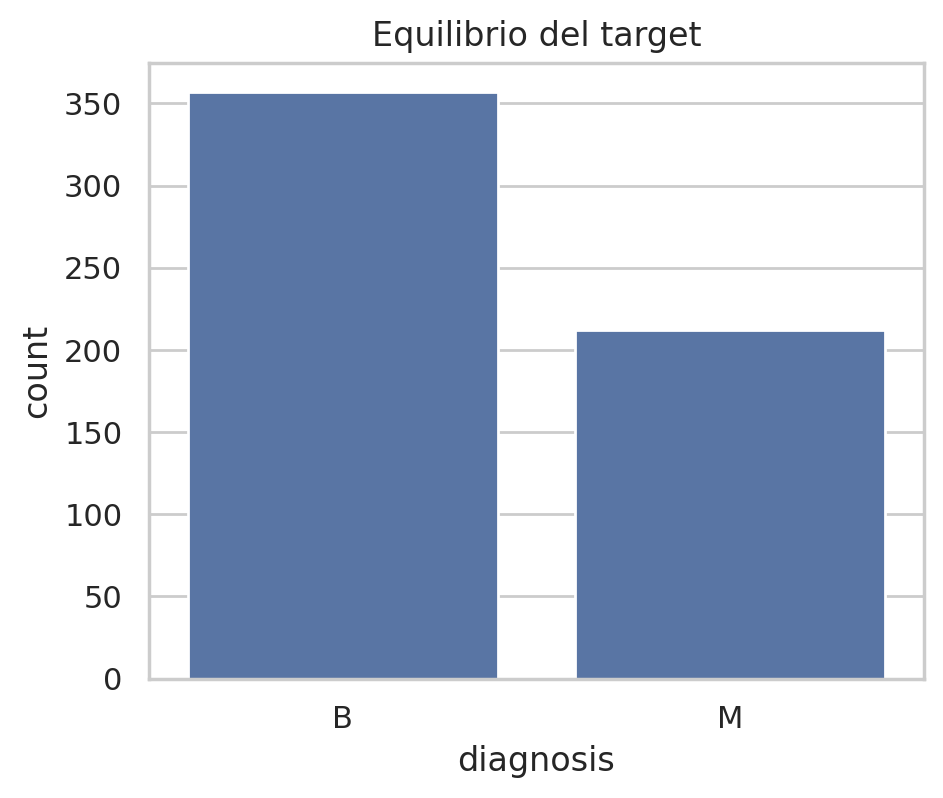

Proporciones: {'B': 0.627, 'M': 0.373}


In [ ]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer_clean.csv'
cancer = pd.read_csv(url, index_col=0)
cancer['diagnosis'] = cancer['diagnosis'].astype('category')
print('Dimensiones:', cancer.shape)
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='diagnosis', data=cancer, ax=ax)
ax.set_title('Equilibrio del target')
plt.show()
print('Proporciones:', cancer['diagnosis'].value_counts(normalize=True).round(3).to_dict())

Hay un desbalanceo moderado (más benignos). Ordenamos las variables por su poder de separación (**F de ANOVA**) y mostramos las 4 más discriminantes.

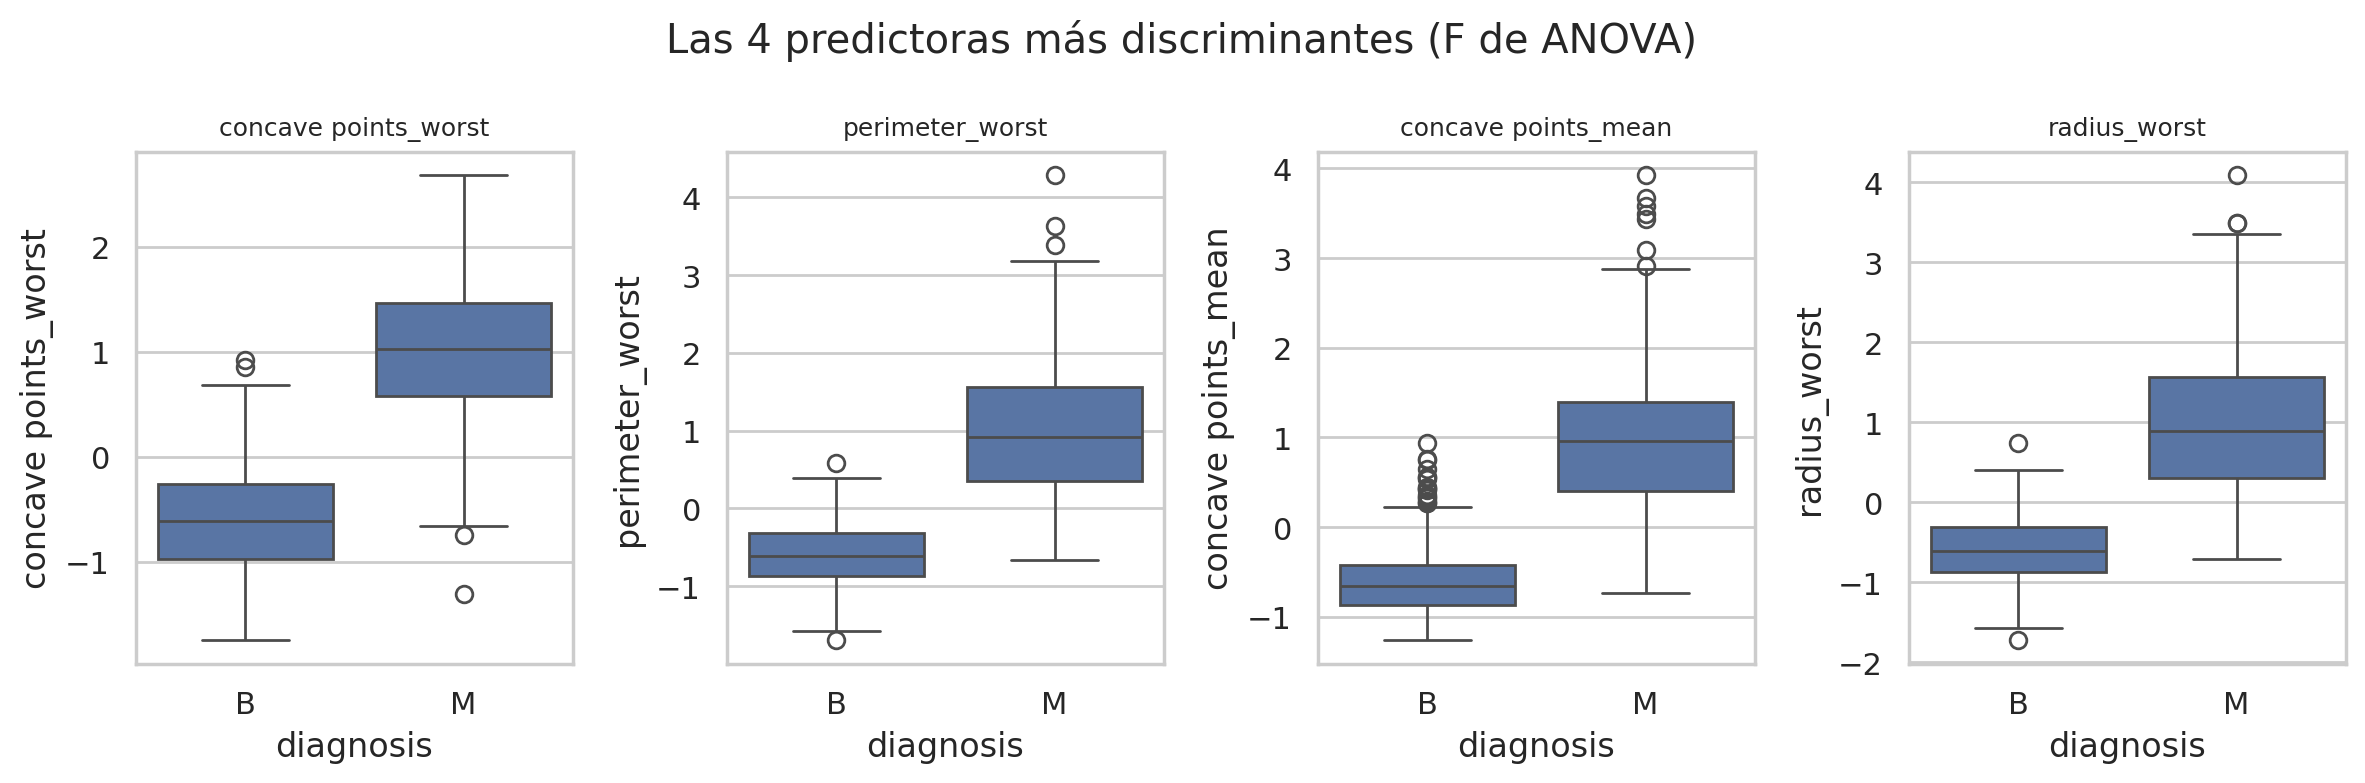

In [ ]:
varpred = [c for c in cancer.columns if c != 'diagnosis']
F, _ = f_classif(cancer[varpred], cancer['diagnosis'])
ranking = pd.Series(F, index=varpred).sort_values(ascending=False)
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for a, v in zip(axes, ranking.index[:4]):
    sns.boxplot(x='diagnosis', y=v, data=cancer, ax=a)
    a.set_title(v, fontsize=9)
plt.suptitle('Las 4 predictoras más discriminantes (F de ANOVA)')
plt.tight_layout()
plt.show()

Preprocesamos (estandarización, **imprescindible** en k-NN) y dividimos.

In [ ]:
strain_raw, stest_raw = split_sample(cancer, 'diagnosis', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'diagnosis')
stest,  _    = preprocesar_datos(stest_raw,  'diagnosis', prep)
xtrain, ytrain = strain.drop('diagnosis', axis=1), strain['diagnosis']
xtest,  ytest  = stest.drop('diagnosis', axis=1),  stest['diagnosis']
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Entrenamiento: (398, 30) | Test: (171, 30)


**Selección de k, distancia y ponderación**

Realizamos el análsiis de validación cruzada con respecto al valor de `k`, `weights`, y `metric` (distancia). Dado que el target está desiquilibrado utilizamos la métrica recall sobre los tumores malignos para realizar este análisis.

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'} | recall CV (M): 0.94


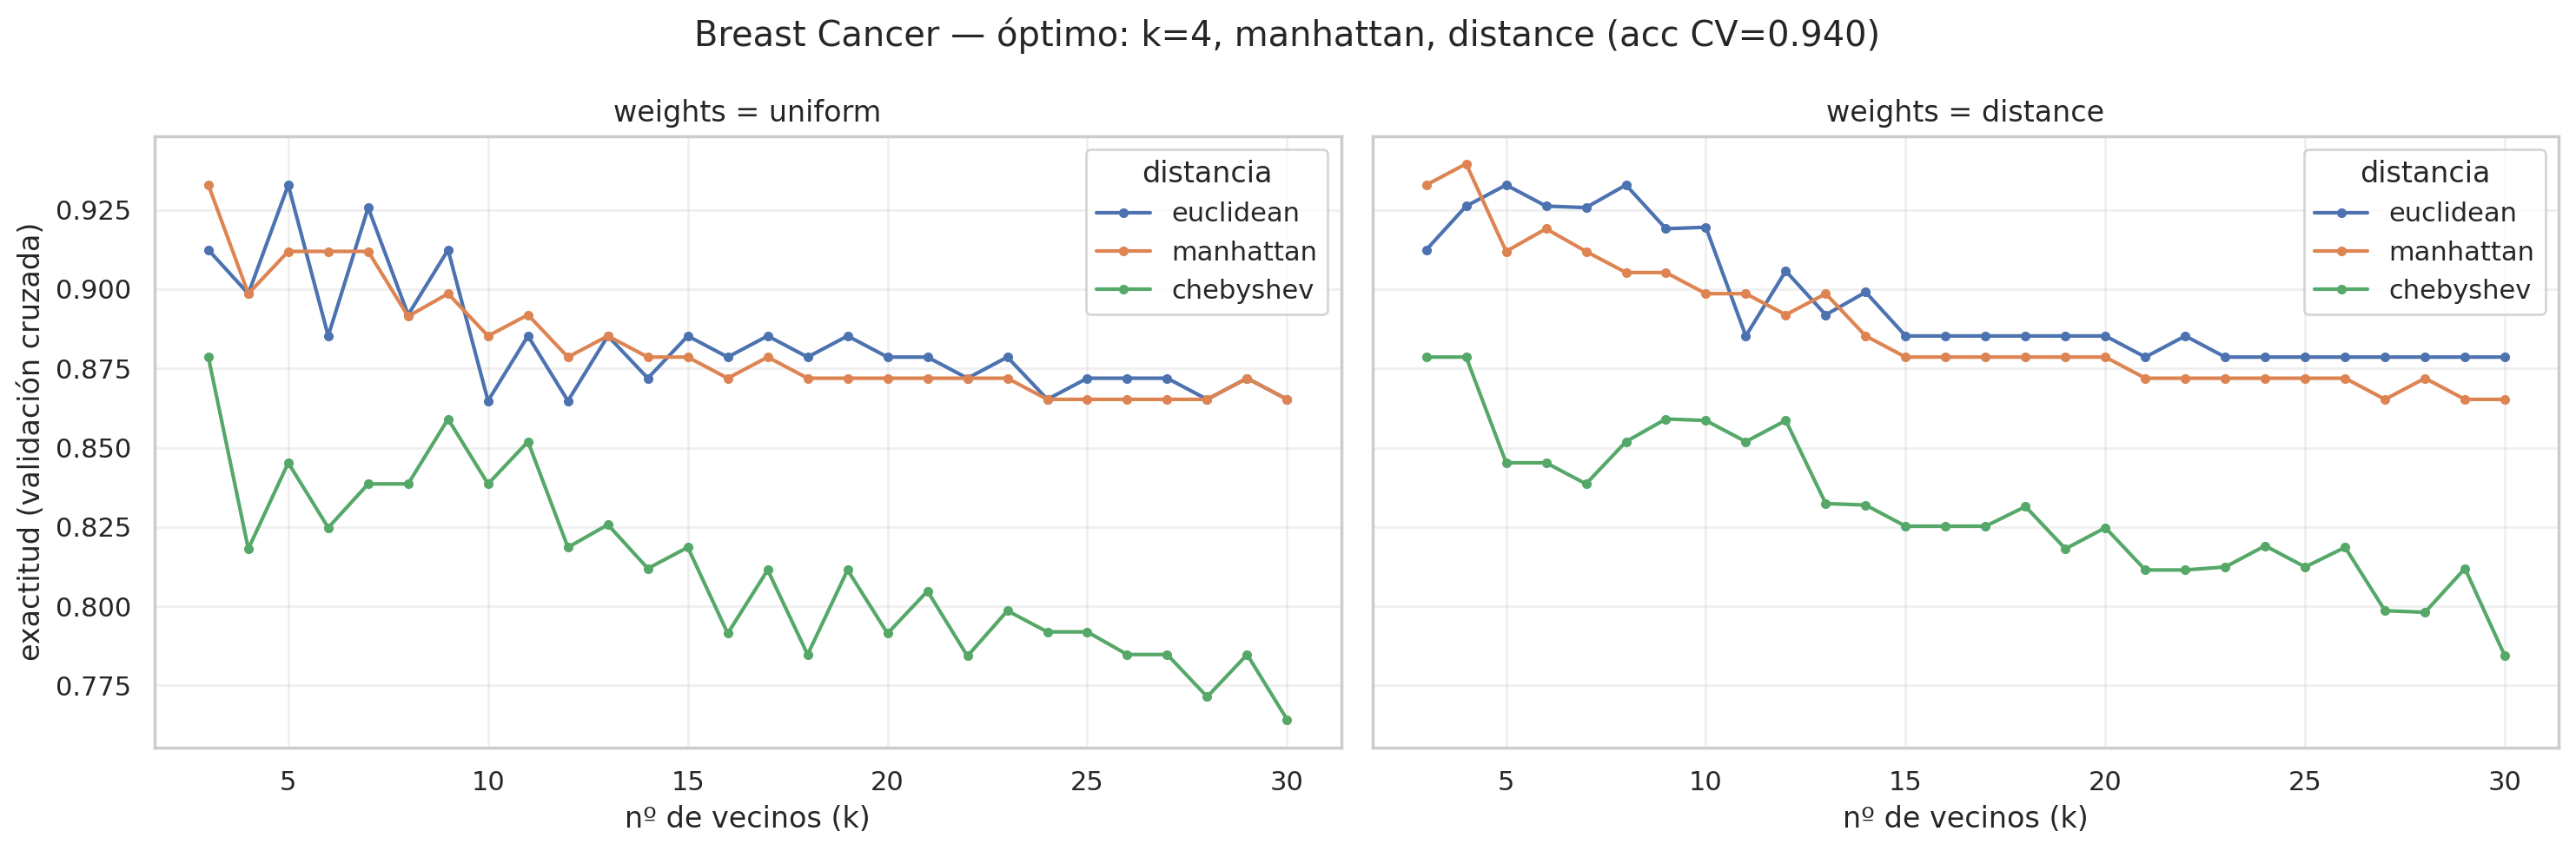

In [ ]:
# Definimos la métrica recall sobre tumores malignos
from sklearn.metrics import make_scorer
recall_m_scorer = make_scorer(recall_score, pos_label='M')
# Grid de búsqueda
pgrid = {'n_neighbors': range(3, 31), 'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan', 'chebyshev']}
# Análisis CV
gs = GridSearchCV(KNeighborsClassifier(), pgrid, scoring=recall_m_scorer, cv=10)
gs.fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_, '| recall CV (M):', round(gs.best_score_, 3))
cv_grafica(gs, ['euclidean', 'manhattan', 'chebyshev'], 'Breast Cancer')

Las curvas muestran cómo evoluciona el recall con $k$ para cada distancia y ponderación. La combinación óptima se obtiene para cuatro vecinos, distancia Manhattan, y ponderación en base a la distancia. El recall para esta combianción es 0.94 para el grupo de los tumores malignos.

Analizamos el modelo obtenido (informe clasificación, matriz, de confusión y validación)

In [ ]:
modelo = gs.best_estimator_
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       1.00      1.00      1.00       250
           M       1.00      1.00      1.00       148

    accuracy                           1.00       398
   macro avg       1.00      1.00      1.00       398
weighted avg       1.00      1.00      1.00       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.96      0.95      0.96       107
           M       0.92      0.94      0.93        64

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



Los resultados del informe de clasificación muestran el buen funcionamiento de clasificador propuesto.

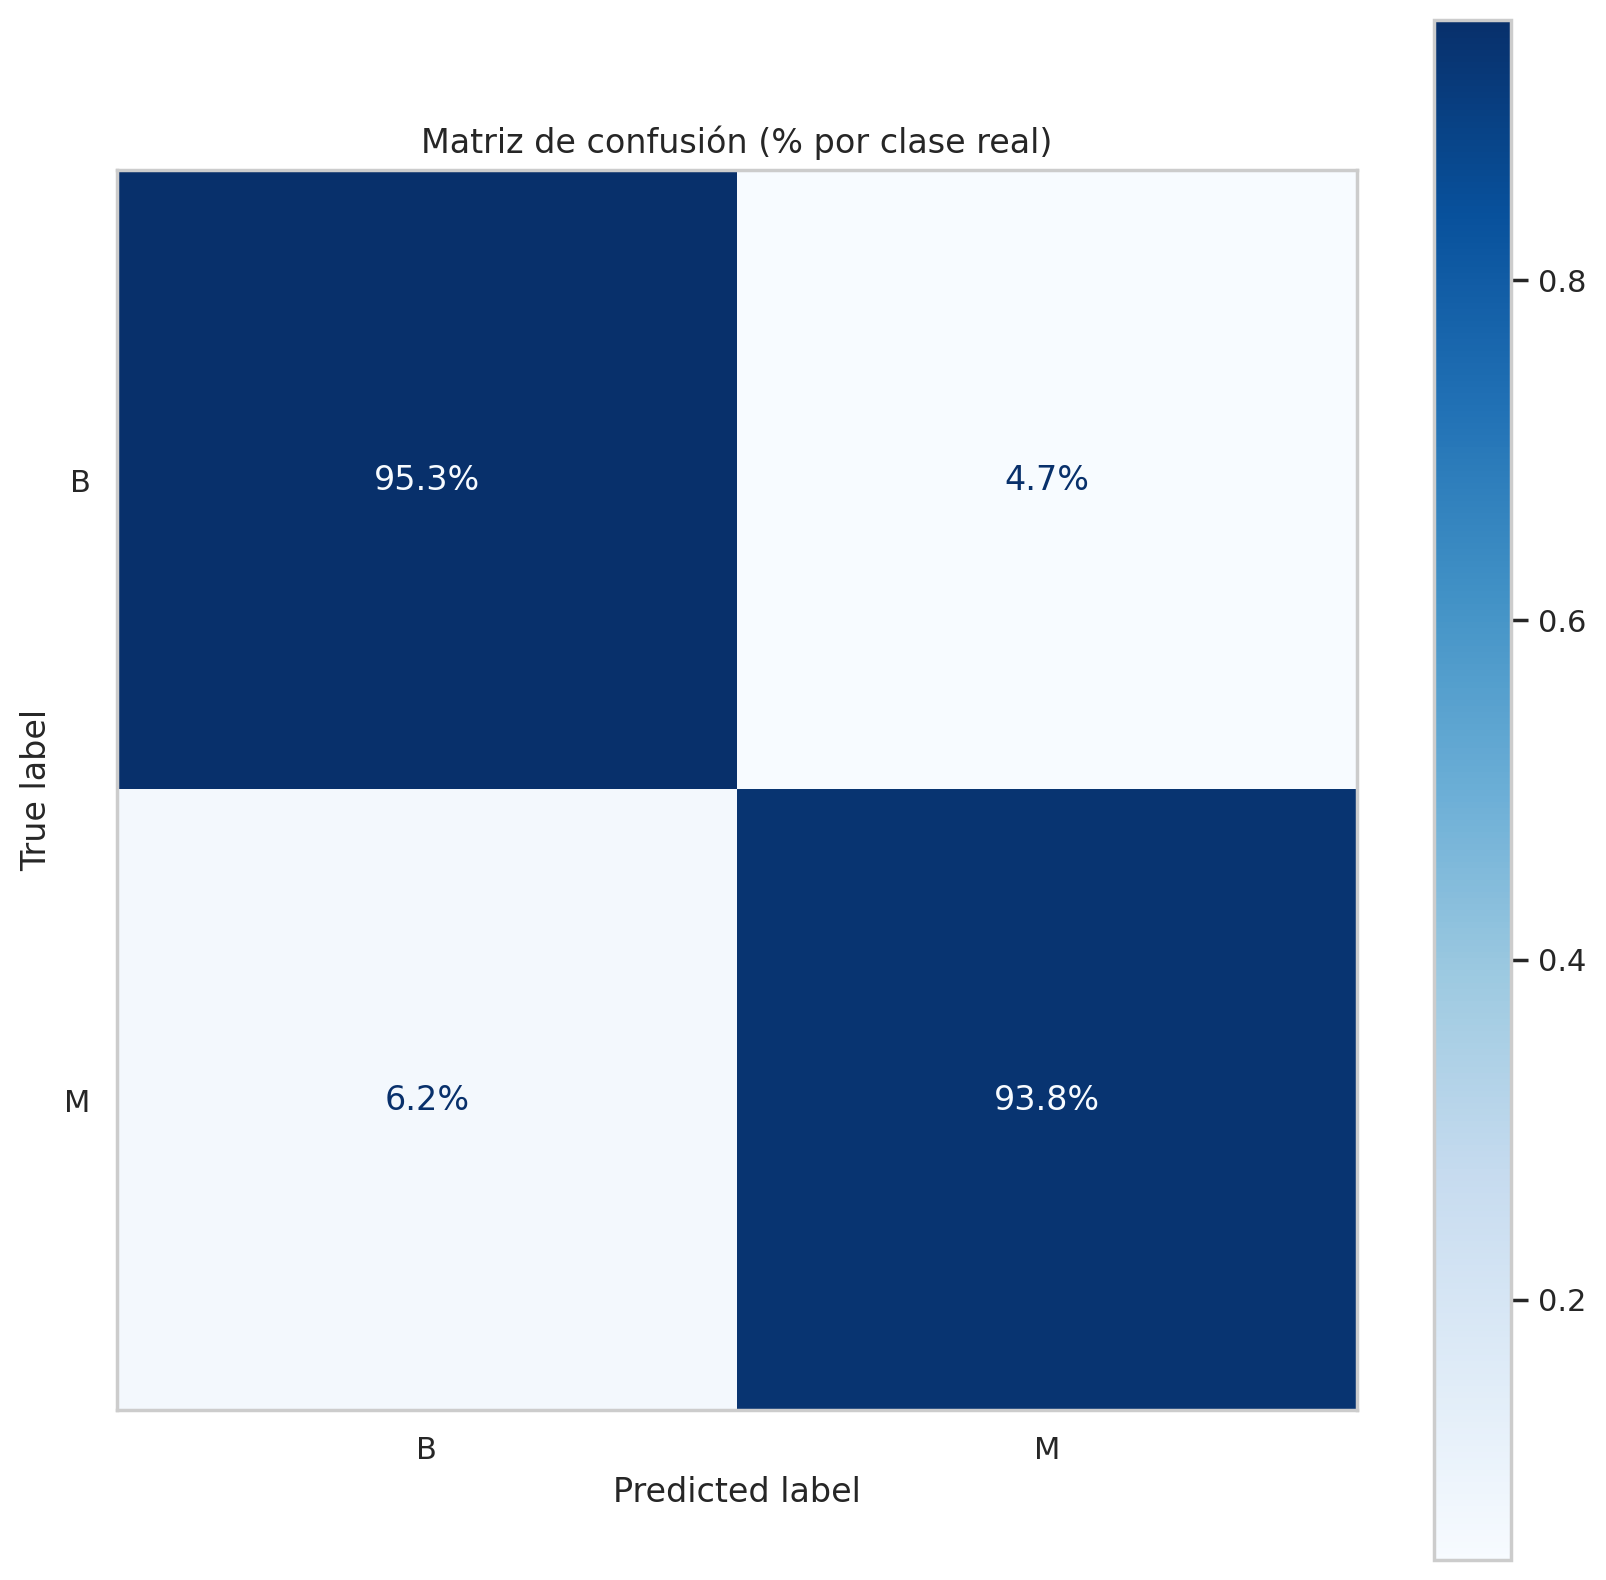

In [ ]:
matriz_confusion(modelo, xtest, ytest);

Por último, realizamos el estudio de validación,  representamos la curva de aprendizaje, y la curva ROC.

In [ ]:
val = validar_modelo(modelo, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.970 +/- 0.024


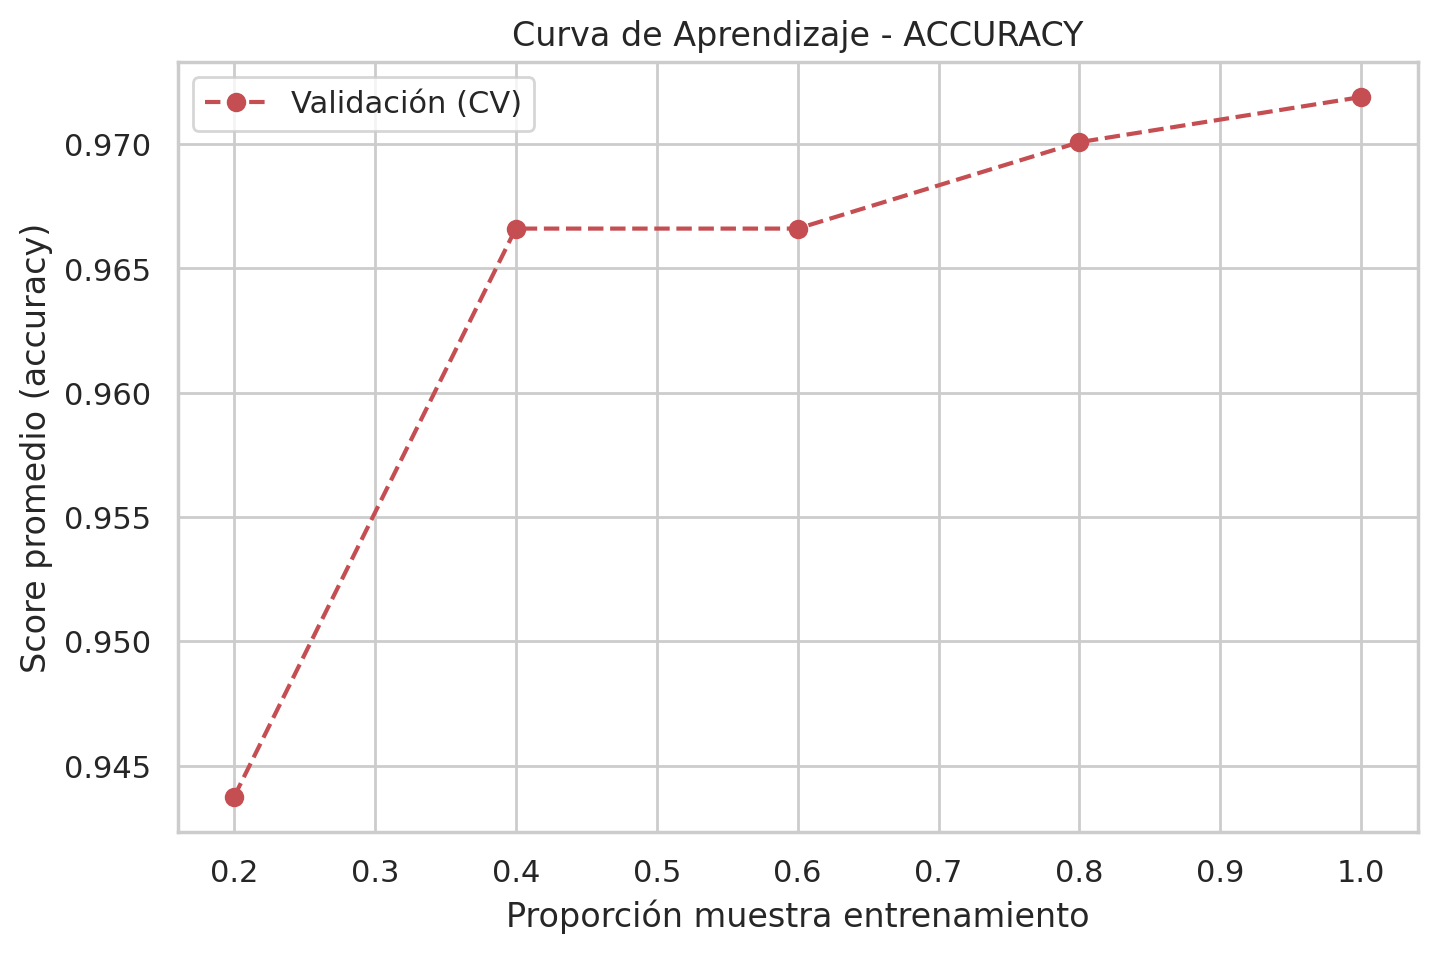

In [ ]:
datos_pp, _ = preprocesar_datos(cancer, 'diagnosis')
X = datos_pp.drop('diagnosis', axis=1)
y = datos_pp['diagnosis']
curva_aprendizaje(modelo, X, y, 'accuracy', 10)

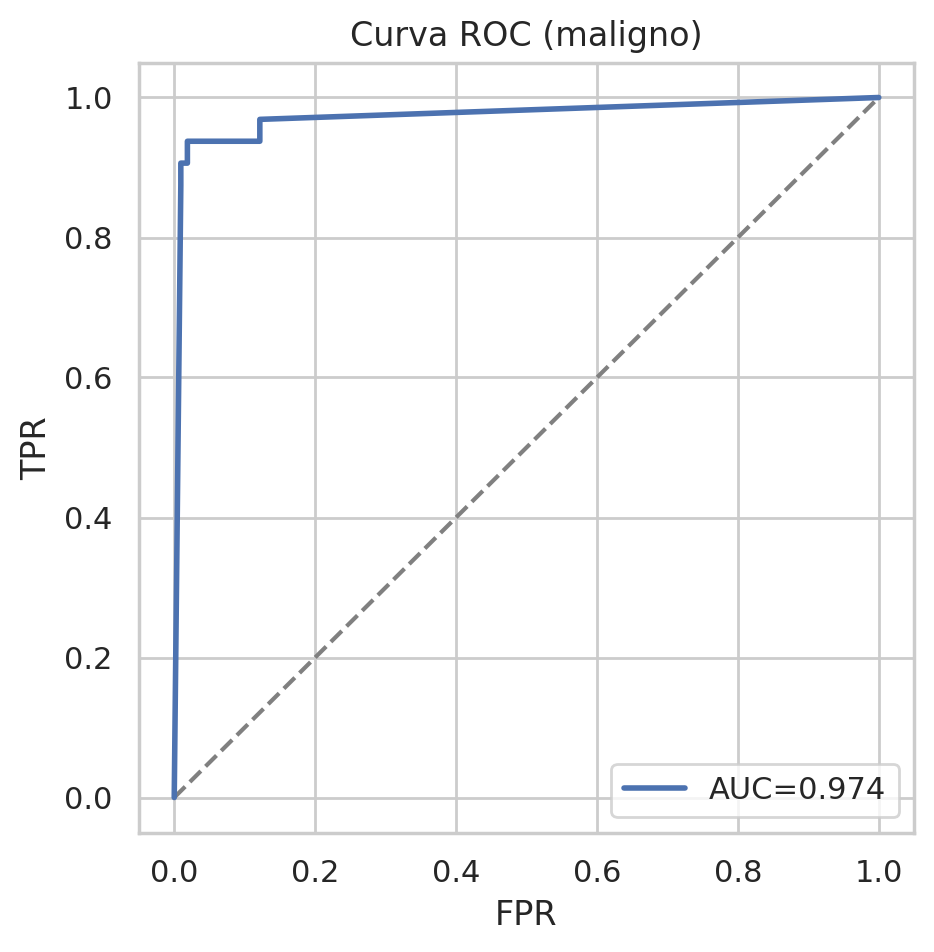

In [ ]:
idx_M = list(modelo.classes_).index('M')
proba_M = modelo.predict_proba(xtest)[:, idx_M]
fpr, tpr, _ = roc_curve((ytest == 'M').astype(int), proba_M); auc = roc_auc_score((ytest == 'M').astype(int), proba_M)
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.plot(fpr, tpr, lw=2, label=f'AUC={auc:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (maligno)')
plt.legend()
plt.show()

El k-NN alcanza una exactitud alta (~0.94) y un AUC próximo a 1. La matriz de confusión y el informe muestran que el error delicado (malignos como benignos) es escaso, y la validación cruzada confirma estabilidad.



### <font color="steelblue">3.1.1. Equilibrado de clases</font>

La clase **maligna** es minoritaria. A diferencia de la regresión logística o el discriminante, **`KNeighborsClassifier` no tiene parámetro `class_weight` ni `priors`**. Aun así podemos equilibrar de dos maneras: (1) con una **ponderación balanceada** —el análogo de `class_weight='balanced'`—, que aprovecha que `predict_proba` da la **proporción de vecinos** de cada clase para **corregirla dividiéndola por la frecuencia** de la clase (dando más peso a las raras) y predecir la de mayor valor corregido; la encapsulamos en una clase `KNNBalanced` para usarla con `matriz_confusion`; y (2) con **remuestreo** del entrenamiento: **SMOTE** (sobremuestreo sintético de la minoría) y **NearMiss** (submuestreo de la mayoría). Comparamos las cuatro opciones.

No esperamos grandes mejoras dado que el modelo obtenido ya funciona bastante bien.

In [ ]:
# (a) Ponderación balanceada: corrige el voto por la frecuencia de cada clase (análogo de class_weight='balanced')
class KNNBalanced:
    def __init__(self, modelo, ytrain):
        self.modelo = modelo; self.classes_ = modelo.classes_
        self.freqs = ytrain.value_counts().reindex(self.classes_).values / len(ytrain)
    def predict(self, X):
        P = self.modelo.predict_proba(X) / self.freqs
        return self.classes_[P.argmax(1)]

# Análisis balanceado
modelo_bal = KNNBalanced(modelo, ytrain)

# (b) y (c) Remuestreo (solo en entrenamiento)
params = gs.best_params_
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
modelo_smote = KNeighborsClassifier(**params).fit(xtr_sm, ytr_sm)
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
modelo_nm = KNeighborsClassifier(**params).fit(xtr_nm, ytr_nm)
print('Tamaños — SMOTE:', ytr_sm.value_counts().to_dict(), '| NearMiss:', ytr_nm.value_counts().to_dict())

Tamaños — SMOTE: {'B': 250, 'M': 250} | NearMiss: {'B': 148, 'M': 148}


Comparamos el reuerdo de malignos en todos los modelos considerados

In [ ]:
resumen = pd.DataFrame({'modelo': ['Base', 'Ponderación balanceada', 'SMOTE', 'NearMiss'],
    'recall_maligno': [recall_score(ytest, m.predict(xtest), pos_label='M') for m in [modelo, modelo_bal, modelo_smote, modelo_nm]],
    'exactitud': [accuracy_score(ytest, m.predict(xtest)) for m in [modelo, modelo_bal, modelo_smote, modelo_nm]]})
resumen.round(3)

,modelo,recall_maligno,exactitud
0,Base,0.938,0.947
1,Ponderación balanceada,0.938,0.942
2,SMOTE,0.938,0.942
3,NearMiss,0.938,0.936


En este conjunto el efecto del equilibrado es **pequeño**: el kNN base ya **detecta bien** la clase maligna (su *recall* es alto), porque los tumores malignos forman un grupo bastante separado. El remuestreo y la ponderación balanceada apenas cambian el *recall* y bajan algo la exactitud global. El equilibrado es **decisivo cuando el desbalanceo es severo o la minoría se detecta mal**, pero aporta poco cuando el modelo ya la captura. La particularidad del kNN es que, al no existir `class_weight`, recurrimos a la **corrección por frecuencia** o al **remuestreo**.



## <font color="steelblue">3.2. Abalones (3 clases)</font>

Clasificamos el **sexo** (M/F/I) de los abalones a partir de medidas morfométricas. Es un problema **difícil** porque machos y hembras adultos son casi indistinguibles.

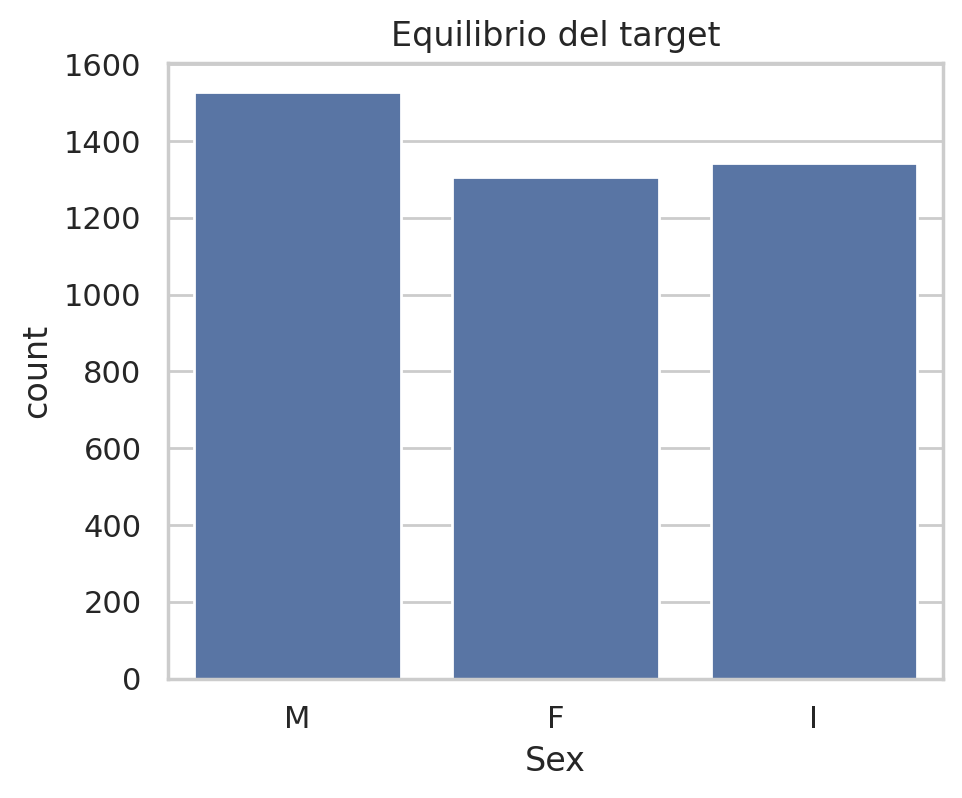

Proporciones: {'M': 0.366, 'I': 0.321, 'F': 0.313}


In [ ]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0)
abalone['Sex'] = abalone['Sex'].astype('category')
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='Sex', data=abalone, order=['M', 'F', 'I'], ax=ax)
ax.set_title('Equilibrio del target')
plt.show()
print('Proporciones:', abalone['Sex'].value_counts(normalize=True).round(3).to_dict())

**Descriptivo.** Las tres clases están **bastante equilibradas** (≈37 % M, 31 % F, 32 % I), por lo que **no** necesita equilibrado. Preprocesamos y dividimos.

In [ ]:
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex')
stest,  _    = preprocesar_datos(stest_raw,  'Sex', prep)
xtrain, ytrain = strain.drop('Sex', axis=1), strain['Sex']
xtest,  ytest  = stest.drop('Sex', axis=1),  stest['Sex']

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


Definimos y evaluamos el grid de búsqueda. Como es un modelo casi equilibrado utilizamos accuracy en lugar de recall.

Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 29, 'weights': 'uniform'} | acc CV: 0.556


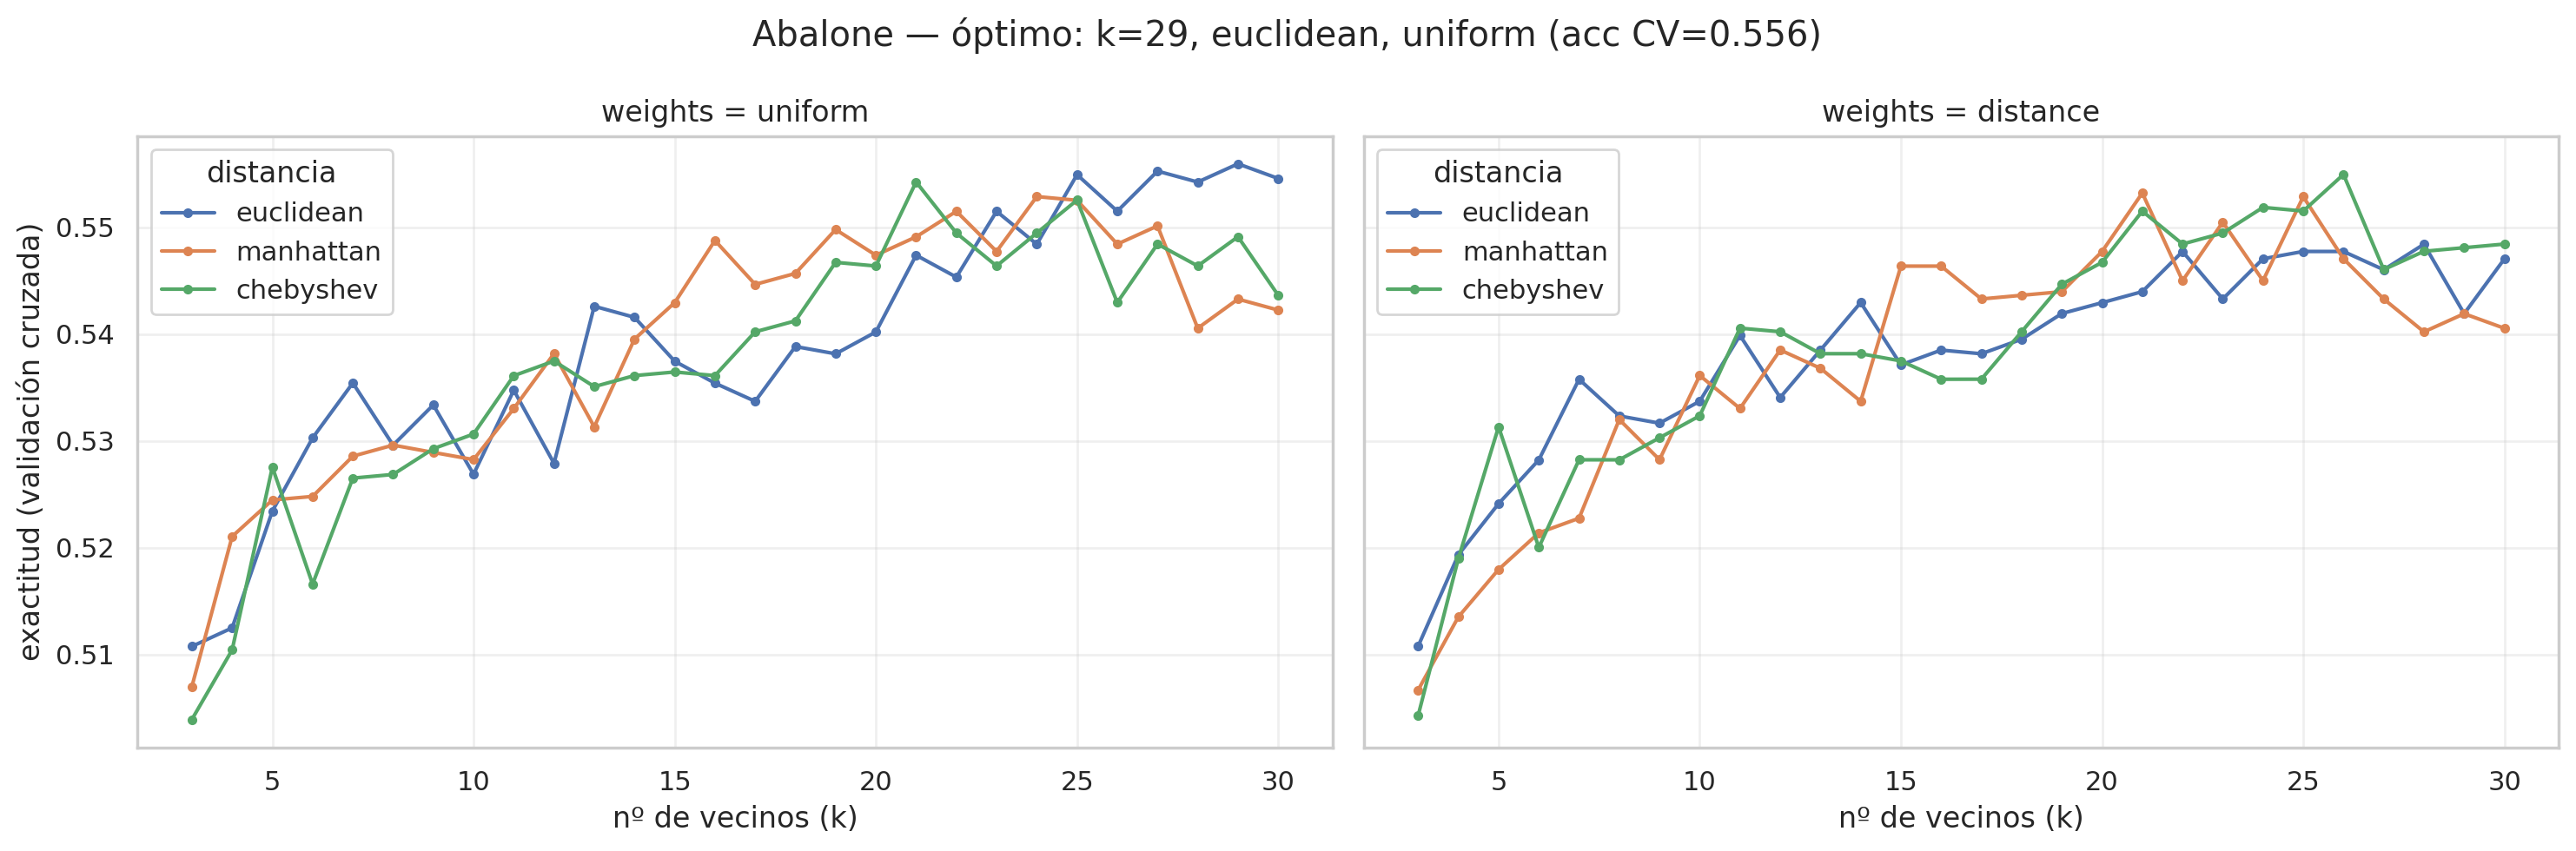

In [ ]:
# Grid de búsqueda
pgrid = {'n_neighbors': range(3, 31), 'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan', 'chebyshev']}
# Proceso de optimización  y gráfico de resultados
gs = GridSearchCV(KNeighborsClassifier(), pgrid, scoring='accuracy', cv=10)
gs.fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_, '| acc CV:', round(gs.best_score_, 3))
cv_grafica(gs, ['euclidean', 'manhattan', 'chebyshev'], 'Abalone')

Aquí el óptimo se alcanza con un $k$ **grande**, señal de que el problema es ruidoso, es decir, hay mucha confusión dentre las clases del target, y conviene **suavizar** mucho.

Evaluamos el mejor modelo obtenido.

In [ ]:
modelo = gs.best_estimator_
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.52      0.46      0.49       915
           I       0.70      0.81      0.75       939
           M       0.53      0.50      0.51      1069

    accuracy                           0.59      2923
   macro avg       0.58      0.59      0.58      2923
weighted avg       0.58      0.59      0.58      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.43      0.38      0.41       392
           I       0.69      0.79      0.73       403
           M       0.49      0.48      0.48       459

    accuracy                           0.55      1254
   macro avg       0.54      0.55      0.54      1254
weighted avg       0.54      0.55      0.54      1254



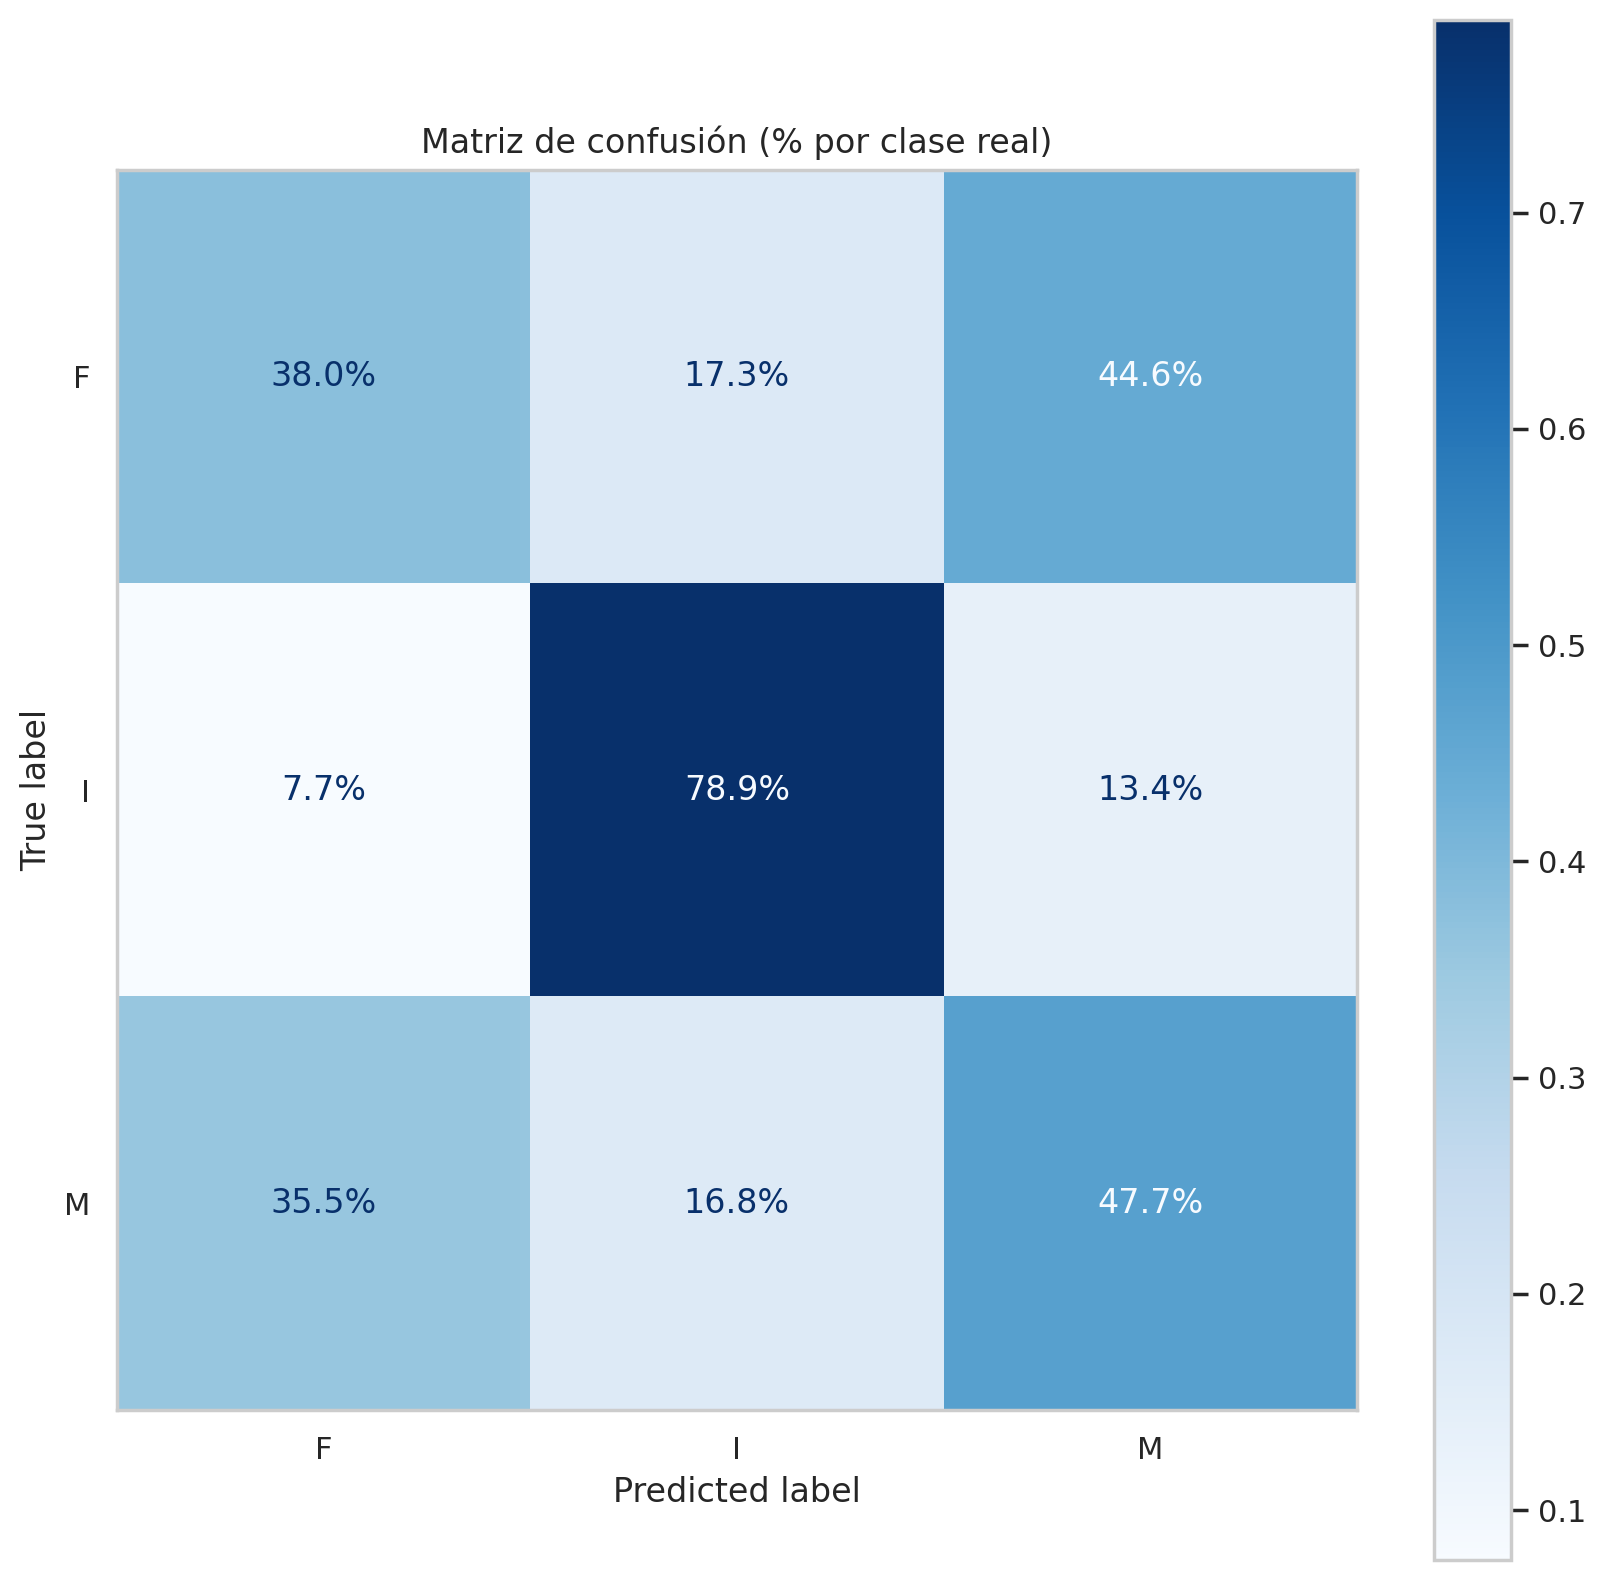

In [ ]:
matriz_confusion(modelo, xtest, ytest);

In [ ]:
val = validar_modelo(modelo, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.556 +/- 0.019


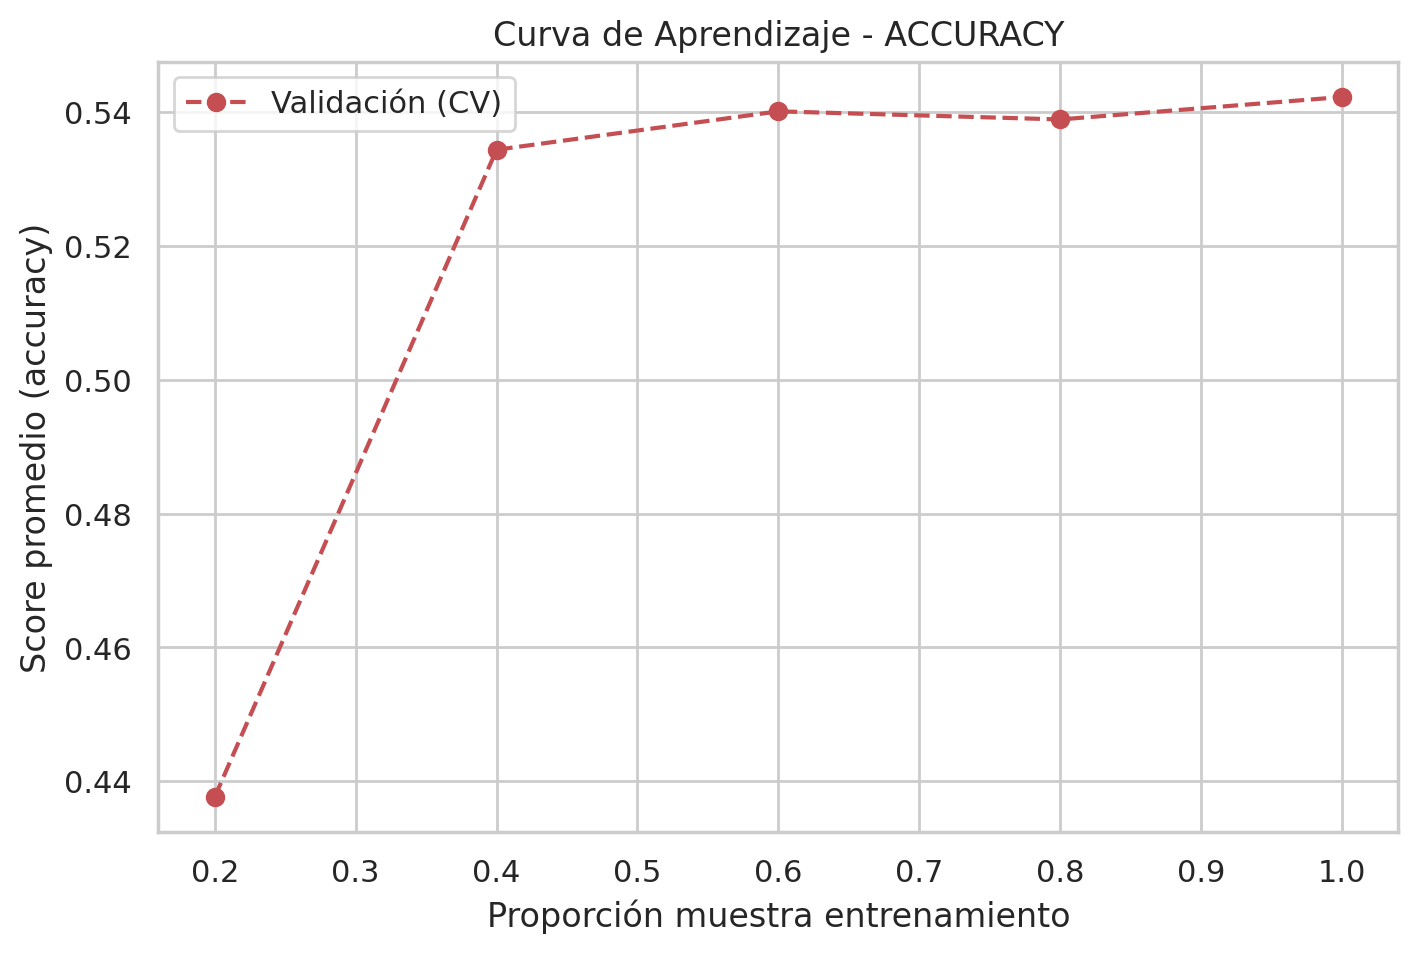

In [ ]:
datos_pp, _ = preprocesar_datos(abalone, 'Sex')
X = datos_pp.drop('Sex', axis=1)
y = datos_pp['Sex']
curva_aprendizaje(modelo, X, y, 'accuracy', 10);

La exactitud se queda en torno al **0.55**: la matriz de confusión muestra que **I** se reconoce razonablemente pero **M y F se confunden mucho** entre sí. La validación cruzada es estable, así que es **dificultad del problema**, no azar. Una redefinición del objetivo (adulto vs. juvenil) podría dar mejores resultados.

### <font color="steelblue">3.2.1. Equilibrado de clases</font>

Aunque las clases están **casi equilibradas** (≈37/31/32 %), aplicamos las mismas estrategias por coherencia con los demás cuadernos y para comprobar su efecto en un caso multiclase. Usamos la **ponderación balanceada** (`KNNBalanced`, que corrige el voto por la frecuencia de cada clase), **SMOTE** y **NearMiss**. Como hay tres clases, resumimos con la **exactitud balanceada** (media de los *recall* por clase), sensible a si mejoran las clases menos favorecidas.

In [ ]:
from sklearn.metrics import balanced_accuracy_score
modelo_bal = KNNBalanced(modelo, ytrain)
params = gs.best_params_
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
modelo_smote = KNeighborsClassifier(**params).fit(xtr_sm, ytr_sm)
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
modelo_nm = KNeighborsClassifier(**params).fit(xtr_nm, ytr_nm)
print('Tamaños — SMOTE:', ytr_sm.value_counts().to_dict(), '| NearMiss:', ytr_nm.value_counts().to_dict())

Tamaños — SMOTE: {'F': 1069, 'I': 1069, 'M': 1069} | NearMiss: {'F': 915, 'I': 915, 'M': 915}


In [ ]:
resumen_ab = pd.DataFrame({'modelo': ['Base', 'Ponderación balanceada', 'SMOTE', 'NearMiss'],
    'exactitud_balanceada': [balanced_accuracy_score(ytest, m.predict(xtest)) for m in [modelo, modelo_bal, modelo_smote, modelo_nm]],
    'exactitud': [accuracy_score(ytest, m.predict(xtest)) for m in [modelo, modelo_bal, modelo_smote, modelo_nm]]})
resumen_ab.round(3)

,modelo,exactitud_balanceada,exactitud
0,Base,0.549,0.547
1,Ponderación balanceada,0.544,0.537
2,SMOTE,0.547,0.538
3,NearMiss,0.552,0.546


Al estar el problema **casi equilibrado**, las estrategias de equilibrado **apenas modifican** los resultados (la exactitud balanceada se mueve muy poco): no hay sesgo hacia una clase mayoritaria que corregir. La dificultad de este banco no es el desbalanceo sino la **confusión intrínseca entre M y F**, que ningún reequilibrado puede resolver. Es un contraejemplo útil: **no siempre hay que equilibrar**, solo cuando el desbalanceo lo justifica.




# <font color="steelblue">4. Referencias</font>

* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 13). Springer.
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 2 y 4).
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Nearest Neighbors*: https://scikit-learn.org/stable/modules/neighbors.html